<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">

<h1 style="margin-bottom:0;"><b>Programming for Data Science  - Group Project </b></h1>

<h1 style="margin-top:5px; color:#357AF6;"><b>“Where Should I Live?” </b></h1>

<h2 style="color:#357AF6; margin-top:-5px;"><b>Leveraging Data to Optimize Quality of Life Choices</b></h2>

<br>

<h3><b>Group 19</b></h3>

<ul style="margin-top:-10px;">
<li><b>Carlota Marto</b> — 20241729</li>
<li><b>Henrique Santos</b> — 20241752</li>
<li><b>Laura Lisboa</b> — 20241783</li>
<li><b>Tiago Carvalho</b> — 20241728</li>
</ul>

<br>

<h4>LCD  —  Teachers: Carina Albuquerque / Sofia Pereira  — 2025/26 </h4>

</div>



<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

    
**Table of Contents**

**1.Introduction**

1.1. Project Goal and Organization

**2. Data Wrangling and Exploratory Analysis**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Handling Inconsistencies \
  2.2.2  Duplicate Records\
  2.2.3. Missing Values - Categorical(1) / Numerical (2-6) \
  2.2.4. Outliers \
  2.2.5. Adjusting Data Types\
  2.2.6. Separating Cities and Countries
</ul>

2.3. Questions Section – 1 to 4

**3. Advanced Topics**

3.1. Web Scraping\
3.2. Interative Map\
3.3 Observation of Web Scraping and Interactive Map


**4. Data Science in Action: Framework and Conclusion**

4.1. Correlation between columns of the dataset\
4.2. Rules for city selection


**5. Conclusions**
</div>





<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Goal and Organization

The primary goal of this Notebook is to perform a **comprehensive**, **data-driven analysis** to empower users in making **informed** living decisions across European countries.\
This project aims to **simplify** the complex choice of where to live by analysing key national characteristics—such as Cost of Living, Population Density, and Employment—and translating **raw data into an interpretable framework**.

Ultimately, this project seeks to answer the central question:\
**Which European countries offer the optimal alignment with a user's personal values and life goals, based on quantitative metrics?**

-------

The project is structured into **three phases**, from raw data preparation to actionable conclusions:
<ul style="margin-top:-10px;">

**-Data Wrangling and Analysis:** Focus on transforming raw data into clean, structured datasets through fundamental exploration techniques to extract relevant initial insights;\
**-Working with Advanced Topics:** Focus on integrating advanced and diverse data sources (e.g., web scraping or geographical data) to reflect the complexity of real-world data collection challenges;\
**-Data Science in Action:** Focus on synthesizing all previous work into a coherent, high-level analysis. The final output is an actionable framework that explores patterns, visualizes relationships, and provides clear, critical conclusions about European living choices.




<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>2. Data Wrangling and Exploratory Analysis </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports
   

Import of Necessary Libraries:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

from bs4 import BeautifulSoup                # process html
from selenium import webdriver               # automate web browser interaction
from selenium.webdriver.common.by import By  #specify specify how to locate elements on a web page.
import requests 

!pip install plotly
!pip install geopandas
!pip install plotly -q #to the output of this don´t appear

import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.graph_objects as go


from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import time


ERROR: Invalid requirement: '#to': Expected package name at the start of dependency specifier
    #to
    ^


Import of the given Dataset:

In [2]:
dataset = pd.read_csv('city_data.csv', sep = '|', header = 1, index_col = 0)
dataset.head()

,Population Density,Population,Working Age Population,Youth Dependency Ratio,Unemployment Rate,GDP per Capita,Days of very strong heat stress,Main Spoken Languages,Average Monthly Salary,Avgerage Rent Price,Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00
"Salzburg, Austria",243.0,375489,250472.0,20.3,3.0,66689.0,0,German,3200,1100,2186,NaN,2023-11-03 00:00:00
"Brussels, Belgium",681.0,3284548,2137425.0,27.5,10.7,62500.0,3,"French, Dutch, Arabic, English",3350,1200,1900,NaN,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.7,6.2,57595.0,3,"Dutch, French, Arabic",2609,900,1953,NaN,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,53311.0,2,"Dutch, French",2400,827,1200,120.0,2023-07-17 00:00:00


<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2 Preprocessing Data
   

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1 Handling Inconsistencies

In [3]:
dataset.columns #This line allows us to see the name of all the columns of the dataset

Index(['Population Density', 'Population', 'Working Age Population ',
       'Youth Dependency Ratio', 'Unemployment Rate', 'GDP per Capita',
       'Days of very strong heat stress', 'Main Spoken Languages',
       'Average Monthly Salary', 'Avgerage Rent Price',
       'Average Cost of Living', 'Average Price Groceries',
       'Last Data Update'],
      dtype='object')

We can observe that the column **'Working Age Population '** has a space in front, which can make it confusing to code with. Also, the column **'Avgerage Rent Price'** has a spelling mistake which we are going to correct.

While analyzing the Project Data table presented in the Project Guidelines, we also decided to change the name of some columns to clear understanding and precision. 

In [4]:
dataset = dataset.rename(columns={'Population Density': 'Population Density (/km2)', 
                                  'Working Age Population ': 'Working Age Population (15-64 years)',
                                  'GDP per Capita': 'GDP per Capita ($)',
                                  'Days of very strong heat stress' : 'Days of very strong heat stress (>38ºC)',
                                  'Average Monthly Salary': 'Average Monthly Salary (€)', 
                                  'Avgerage Rent Price' : 'Average Rent Price (€)',
                                 })

In [5]:
dataset.head(1)

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita ($),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,55770.0,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


The variable **'GDP per Capita'** is measured in $ and, as there are other two columns where the values are measured in €,so, we are going to do the conversion of all the values in that column. We are sure that, that way, it is less confusing for someone trying to find the best place to live.\

For **simplicity**, we are going to consider the cost of 1 dolar equal to 0.87 euros (present price) and **not** the price of 1 dolar in euros in the given date of last data update for each city. 

In [6]:
dataset['GDP per Capita ($)'] = dataset['GDP per Capita ($)'] * 0.87  

In [7]:
dataset = dataset.rename(columns={'GDP per Capita ($)' : 'GDP per Capita (€)'})
dataset.head(1)

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,340.0,2024-06-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [8]:
duplicate_records = dataset[dataset.duplicated(keep = False)]
duplicate_records
#these two lines shows us the duplicate records in the dataset

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,NaN,2023-06-29 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,NaN,2023-11-27 00:00:00


In the whole dataset we only have two duplicates: Berlin and Malaga. In the next line of code we are removing them.

In [9]:
dataset.drop_duplicates(inplace = True)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.3. How to Handle Missing Values

Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [10]:
dataset.isna().sum()

Population Density (/km2)                   1
Population                                  0
Working Age Population (15-64 years)        1
Youth Dependency Ratio                      0
Unemployment Rate                           1
GDP per Capita (€)                          1
Days of very strong heat stress (>38ºC)     0
Main Spoken Languages                       1
Average Monthly Salary (€)                  0
Average Rent Price (€)                      0
Average Cost of Living                      0
Average Price Groceries                    78
Last Data Update                            0
dtype: int64

We can conclude that exist 6 variables with missing values - 1 Categorical and 5 Numerical.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b> 2.2.3. How to Handle Missing Value - Categorical Variables


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
1. Only in **'Main Spoken Languages'**  is missing a categorical variable - We first need to understand in what row is the missing value located:

In [11]:
dataset[dataset['Main Spoken Languages'].isna()]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,NaN,3200,1100,2050,NaN,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

As it is a **categorical** variable we have to deal with it with the mode. If we did not have the information about the country of the city, we would apply the mode to all the cities in the dataset, but, as we know that "Dusseldorf" is located in Germany we only apply the mode to all the **german cities** for a more accurate result:

In [12]:
dataset.loc[dataset.index.str.contains('Germany'), ['Main Spoken Languages']].mode()

,Main Spoken Languages
0,German


As we can observe, the most common main spoken language in german cities of the dataset is **'German'**. Therefore, we will replace the missing value with 'German':

In [13]:
dataset.loc['Dusseldorf, Germany', 'Main Spoken Languages'] = 'German'
dataset.loc[['Dusseldorf, Germany']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Average Price Groceries,Last Data Update
City,,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,NaN,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.3. How to Handle Missing Value - Numerical Variables

We can do many things with missing numerical values. There are cases where we must replace with the **median** and others where we must use the **mean**. This all depends if those columns have outliers or not, therefore, we decided that the best way to verify outliers is by creating a **boxplot for each variable**. As the columns with missing values have very different scales, we cannot put them all in the same graphic.\
\
**Note:** It is generally preferable to use the mean rather than the median when there are no outliers. However, if outliers are present, the median is more appropriate because it is not affected by extreme values.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

2. In the column **'Average Price Groceries' there are 80 missing values out of the 86 rows total.** As there are only 6 records of average price groceries, this does not add up any valuable information, therefore, we decided to remove it.  -   Here doesn´t make sense filling the missing values.

In [14]:
dataset.drop('Average Price Groceries', axis = 1, inplace = True)
dataset.head(1) #this is just to visualise that the columns is not there anymore

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Vienna, Austria",310.0,2983513,2018818.0,20.1,10.2,48519.9,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

3. For the missing value in the column **'Working Age Population'**, by the same logic in 1. we will replace it based on the other **german cities** as the only missing value is also located in Dusseldorf in Germany (seen is 1.).


In [15]:
dataset[dataset['Working Age Population (15-64 years)'].isna()]
#Here we can confirm that the only missing value is actually in a german city

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,NaN,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


In [16]:
german_cities = dataset[dataset.index.str.contains('Germany')]
german_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Berlin. Germany,304.0,5303922,3481212.0,21.3,4.7,40496.76,3,"German, Turkish, Arabic, English",3200,1220,2200,2023-06-29 00:00:00
"Hamburg, Germany",461.0,3315036,2181857.0,21.5,3.2,53120.46,0,"German, English, Turkish",3500,1100,2100,2024-07-10 00:00:00
"Munich, Germany",529.0,2907752,1955041.0,21.1,2.1,73049.55,1,"German, English",3540,1500,2550,2023-03-16 00:00:00
"Cologne, Germany",1233.0,2002550,1335299.0,20.8,3.9,52469.70,3,"German, English, Turkish",3200,1030,2000,2024-11-23 00:00:00
"Frankfurt am Main, Germany",631.0,2710501,1791435.0,22.0,3.2,60353.64,6,"German, English",3800,1300,2350,2023-02-04 00:00:00


**Verifying the existence of outliers:**

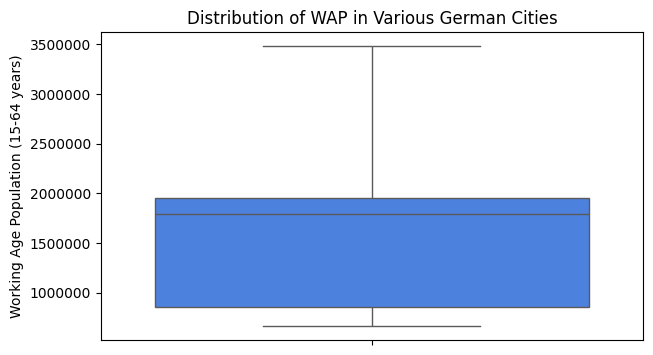

In [17]:
plt.figure(figsize = (7,4))
sns.boxplot(data = german_cities['Working Age Population (15-64 years)'], color ='#357AF6')
plt.title('Distribution of WAP in Various German Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in the Working Age Population in German cities, therefore we use mean:

In [18]:
dataset.loc['Dusseldorf, Germany', ['Working Age Population (15-64 years)']] =  german_cities['Working Age Population (15-64 years)'].mean().round()
dataset.loc[['Dusseldorf, Germany']]
#This two lines replace the missing value by the mean and display the row with information about Dusseldorf, Germany.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Dusseldorf, Germany",1295.0,1554077,1658169.0,21.4,3.3,61977.06,3,German,3200,1100,2050,2024-01-15 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
4. Missing Value in **'Population Density':**

In [19]:
dataset[dataset['Population Density (/km2)'].isna()]	
#this line allows us to see what city has the missing value in Population Density

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

By the same logic as the last one, we're going to compare Valencia to the other spainish cities and then, see the distribution of the Population Density in those cities:

In [20]:
spanish_cities = dataset[dataset.index.str.contains('Spain')]
spanish_cities.head()
#this line creates a new dataset with the information of german cities only

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Madrid, Spain",873.0,6882461,4617753.0,23.0,10.8,44387.40,18,Spanish,2271,1100,1589,2023-05-14 00:00:00
"Barcelona, Spain",1918.0,5034925,3331345.0,22.6,11.0,39163.92,0,"Spanish, Catalan",2094,1450,1630,2024-10-18 00:00:00
"Valencia, Spain",NaN,1748142,1162828.0,22.6,13.7,29205.90,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00
"Seville, Spain",330.0,1549641,1037225.0,25.0,21.6,26103.48,53,Spanish,2300,650,1150,2024-09-01 00:00:00
"Malaga, Spain",571.0,869096,585608.0,23.5,17.7,24093.78,0,"Spanish, English",2200,1312,1400,2023-11-27 00:00:00


**Verifying the existence of outliers:**

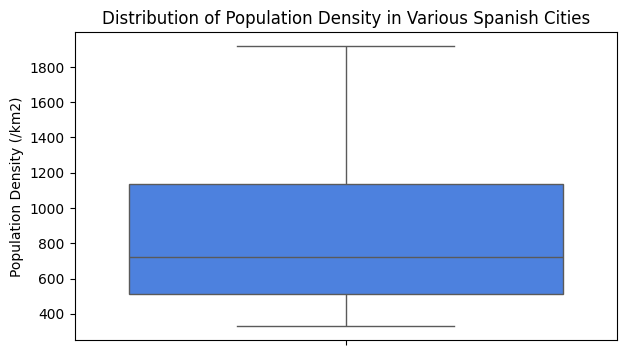

In [21]:
plt.figure(figsize = (7,4))
sns.boxplot(data = spanish_cities['Population Density (/km2)'], color = '#357AF6')
plt.title('Distribution of Population Density in Various Spanish Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in Population Density in German cities, therefore we use mean:

In [22]:
dataset.loc['Valencia, Spain', ['Population Density (/km2)']] =  spanish_cities['Population Density (/km2)'].mean()
dataset.loc[['Valencia, Spain']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Valencia, Spain",923.0,1748142,1162828.0,22.6,13.7,29205.9,5,Spanish;Valencian,2400,1190,1300,2023-06-04 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
5. Missing Value in **'Unemployment Rate':**

In [23]:
dataset[dataset['Unemployment Rate'].isna()]
#this line allows us to see what city has the missing value in Unemployment Rate.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


In [24]:
belgium_cities = dataset[dataset.index.str.contains('Belgium')]
belgium_cities.head()
#this line creates a new dataset with the information of Belgium cities only.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Brussels, Belgium",681.0,3284548,2137425.0,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22 00:00:00
"Antwerp, Belgium",928.0,1139663,723396.0,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09 00:00:00
"Gent, Belgium",552.0,645813,417832.0,24.80,NaN,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00
"Bruges, Belgium",840.0,119765,74600.0,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25 00:00:00


**Verifying the existence of outliers:**

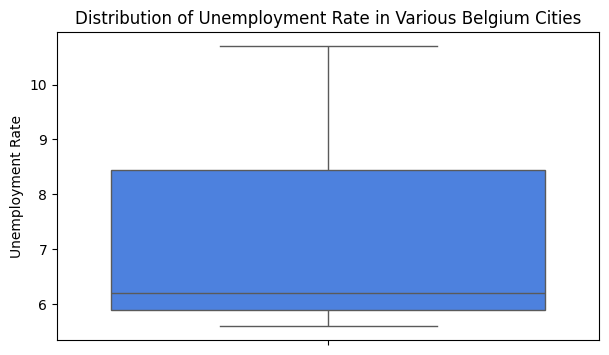

In [25]:
plt.figure(figsize = (7,4))
sns.boxplot(data = belgium_cities['Unemployment Rate'], color = '#357AF6')
plt.title('Distribution of Unemployment Rate in Various Belgium Cities')
plt.ticklabel_format(style = 'plain', axis = 'y')

**Conclusion:** As we can see above, there are no outliers in Unemployment Rate in Belgium cities, therefore we use mean:

In [26]:
dataset.loc['Gent, Belgium', ['Unemployment Rate']] =  belgium_cities['Unemployment Rate'].mean()
dataset.loc[['Gent, Belgium']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Gent, Belgium",552.0,645813,417832.0,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17 00:00:00


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
6. Missing Value in **'GDP per Capita':**

In [27]:
dataset[dataset['GDP per Capita (€)'].isna()]	
#this line allows us to see what city has the missing value in GDP per Capita.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


In [28]:
cyprus_cities = dataset[dataset.index.str.contains('Cyprus')]
cyprus_cities.head()
#this line creates a new dataset with the information of Cyprus cities only.

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Lefkosia, Cyprus",130.0,356400,237000.0,23.06,9.6,30369.09,45,"Greek, Turkish, English",1486,700,1350,2024-04-08 00:00:00
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,NaN,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

As there are only **two cities in Cyprus**, we can only impute a value in the missing value based on the other city, therefore we decided that we are going to use the same value for both:

In [29]:
dataset.loc['Lemesos;Cyprus', ['GDP per Capita (€)']] =  dataset.loc['Lefkosia, Cyprus', ['GDP per Capita (€)']]
dataset.loc[['Lemesos;Cyprus']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
Lemesos;Cyprus,190.0,262238,173906.0,23.06,11.2,30369.09,0,"Greek, English, Russian",2500,1400,2300,2023-08-14 00:00:00


In [30]:
dataset.isna().sum() #just to check the final result 

Population Density (/km2)                  0
Population                                 0
Working Age Population (15-64 years)       0
Youth Dependency Ratio                     0
Unemployment Rate                          0
GDP per Capita (€)                         0
Days of very strong heat stress (>38ºC)    0
Main Spoken Languages                      0
Average Monthly Salary (€)                 0
Average Rent Price (€)                     0
Average Cost of Living                     0
Last Data Update                           0
dtype: int64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
------------------------------------------------------------------- **ALL MISSING VALUES TREATED** -------------------------------------------------------------------------

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.4 Outliers

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
In city-level data, extreme values often correspond to large metropolitan areas rather than data errors. Therefore, statistical outliers should be carefully evaluated in context before being removed, as they may represent meaningful real-world phenomena. For this reason, outlier removal was not performed in this study, since it would not be methodologically appropriate for the objectives of our analysis.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.5 Adjusting Data Types

In [31]:
dataset.info()
#this line allows us to see the datatype of each column

<class 'pandas.core.frame.DataFrame'>
Index: 84 entries, Vienna, Austria to Adana, Turkiye
Data columns (total 12 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Population Density (/km2)                84 non-null     float64
 1   Population                               84 non-null     int64  
 2   Working Age Population (15-64 years)     84 non-null     float64
 3   Youth Dependency Ratio                   84 non-null     float64
 4   Unemployment Rate                        84 non-null     float64
 5   GDP per Capita (€)                       84 non-null     float64
 6   Days of very strong heat stress (>38ºC)  84 non-null     int64  
 7   Main Spoken Languages                    84 non-null     object 
 8   Average Monthly Salary (€)               84 non-null     int64  
 9   Average Rent Price (€)                   84 non-null     int64  
 10  Average Cost of Living         

&nbsp;&nbsp;&nbsp;&nbsp;As we can see, there are some columns classified as 'float64' that do not make sense. For example, the Working Age Population and the Population Density. We decided to change them to integers to make it easier to read. The column `Last Data Update` also need to be change to a datatime type as it represents a real date not a string.

**Adjusted Data Types:**

In [32]:
dataset['Last Data Update'] = pd.to_datetime(dataset['Last Data Update'])

In [33]:
dataset['Population Density (/km2)'] = dataset['Population Density (/km2)'].astype(int)
dataset['Working Age Population (15-64 years)'] = dataset['Working Age Population (15-64 years)'].astype(int)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 2.2.6 Separating Cities and Countries

While analysing the city_data.cvs file we noticed that in the line 48 in column City, instead of (city,country) register is written (county,city):

In [34]:
dataset.rename(index ={'Greece, Athens': 'Athens, Greece'}, inplace = True)
dataset.loc[['Athens, Greece']]
#Changing the order

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update
City,,,,,,,,,,,,
"Athens, Greece",1829,3530371,2287174,22.0,17.2,33564.6,17,"Greek, English",1050,600,1200,2024-07-16


Now is possible to create 2 columns, one with only the City name and other with only the respective Country name:

In [35]:
dataset = dataset.reset_index().rename(columns={'index': 'City'}) 
dataset['City'] = dataset['City'].astype(str) 
dataset[['City','Country']] = dataset['City'].str.split(r'[.,;]', expand = True) #
#This separates cities from contrys independently of having ".", "," or ";" in the middle of them. 

In [36]:
dataset.set_index('City', inplace = True)
dataset.head()

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country
City,,,,,,,,,,,,,
Vienna,310,2983513,2018818,20.1,10.2,48519.90,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15,Austria
Salzburg,243,375489,250472,20.3,3.0,58019.43,0,German,3200,1100,2186,2023-11-03,Austria
Brussels,681,3284548,2137425,27.5,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,Belgium
Antwerp,928,1139663,723396,27.7,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,Belgium
Gent,552,645813,417832,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium


<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

**2.3. Questions Section**


  **Notes**: **1.** City is defined as Index ; **2.** One city = One row

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">

**1.a) Which country appears most frequently in the dataset? How many cities are associated with it?**


In [37]:
most_frequent_country = dataset['Country'].mode()[0] #calculates the mode of countries

print(f"Answer 1: The most frequent Country is: {most_frequent_country}")

Answer 1: The most frequent Country is:  Germany


In [38]:
count_cities = dataset[dataset['Country'] == most_frequent_country].shape[0] #counts how many rows are associated with most_frequent_country
 
print(f"Answer 2: {count_cities} cities are associated with {most_frequent_country}.")

Answer 2: 10 cities are associated with  Germany.


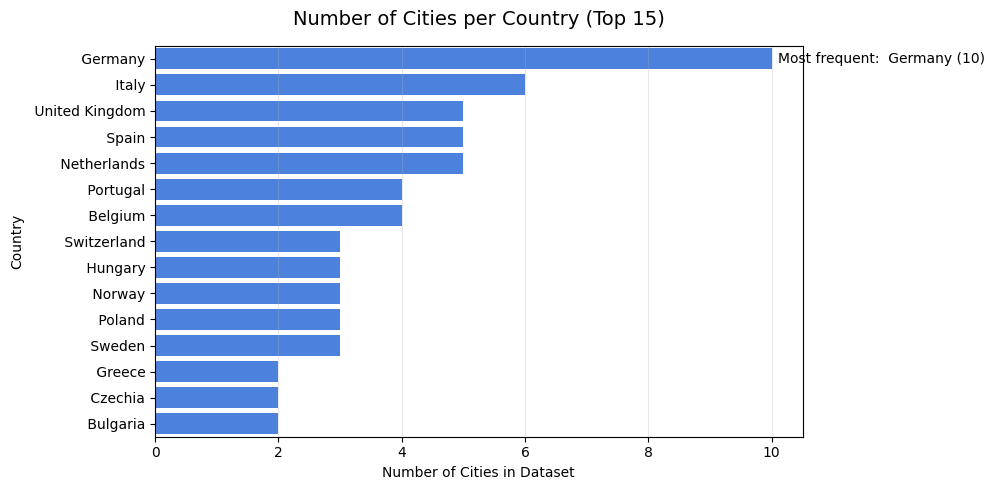

In [39]:
# Count cities per country
country_counts = dataset['Country'].value_counts()

# Identify the most frequent country and its count
top_country = country_counts.idxmax()
top_count = country_counts.max()

# Plot: top countries (to keep it readable)
top_n = 15
plot_data = country_counts.head(top_n).reset_index()
plot_data.columns = ['Country', 'Number of Cities']

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=plot_data,
    x='Number of Cities',
    y='Country',
    color='#357AF6'
)

plt.title(f'Number of Cities per Country (Top {top_n})', fontsize=14, pad=15)
plt.xlabel('Number of Cities in Dataset')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)

# Annotate the top country
ax.text(
    x=top_count + 0.1,
    y=list(plot_data['Country']).index(top_country),
    s=f"Most frequent: {top_country} ({top_count})",
    va='center'
)

plt.tight_layout()
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Interpretation:**

The chart shows that Germany is the most represented country in the dataset, with 10 cities, followed by Italy and the United Kingdom. This indicates that the dataset is not evenly distributed across countries, with some countries contributing substantially more observations than others. As a result, analyses performed at the city level may be disproportionately influenced by highly represented countries, particularly Germany. Therefore, for fair cross-country comparisons, it is more appropriate to rely on country-level aggregates rather than Europe-wide city-level averages.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**1.b) How many cities are present in total? How many are associated with Greece?**


In [40]:
total_cities = dataset.index.shape[0]
print(f'Answer 1: In total are present {total_cities} cities.')


Answer 1: In total are present 84 cities.


In [41]:
greece_cities = dataset['Country'].str.contains("Greece", case=False).sum()
print(f'Answer 2: Number of cities in Greece is {greece_cities}.')


Answer 2: Number of cities in Greece is 2.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Interpretation:**

The dataset contains 84 cities in total, of which only 2 are located in Greece. This highlights a strong imbalance in country representation, with Greece being underrepresented relative to several other European countries. As a consequence, city-level results for Greece may not be fully representative of national conditions and should be interpreted with caution. For analyses that compare countries, relying on country-level averages or medians rather than individual cities helps mitigate this limitation and leads to more robust and meaningful conclusions about European urban patterns.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**1.c) Which is the least spoken language in the dataset? Which are the top 3 most spoken languages?**

As there are cities in which there's more than one main spoken language, our solution was to create a list with all the languages spoken in all the cities (even if they are repeated) and then, create a counter that counts how many times each language appears on the list.

In [42]:
counter = dataset['Main Spoken Languages'].str.split(r'[,;]').explode().str.strip().value_counts()
#This line creates a counter that counts how many times each language appears on the list
#the split(r'[,;]') splits the string at each comma or semicolon
#the explode() transforms the elements to a list

top_3_languages = counter.head(3)
print('Answer 3:')
print(top_3_languages)
print('Answer 2: The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.')

least_spoken = counter.index[-1]
count_least_spoken = counter.iloc[-1]

print(f"Answer 1: The least spoken language is {least_spoken} with a count of {count_least_spoken}.")
#There are more than one language that only appear once in the dataset but Slovene is the one that appears in the last position in the list.

Answer 3:
Main Spoken Languages
English    46
German     15
Turkish    10
Name: count, dtype: int64
Answer 2: The top 3 spoken languages are English, German and Turkish. With the counts of 46, 15 and 10 respectively.
Answer 1: The least spoken language is Slovene with a count of 1.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Interpretation:**

The language distribution in the dataset is highly uneven. English is the most frequently spoken language, appearing in 46 cities, followed by German and Turkish. This reflects both the widespread use of English as an international language across European cities and the higher representation of countries where German and Turkish are spoken. In contrast, Slovene appears only once, indicating that some languages are represented by very few cities. This imbalance suggests that linguistic diversity in the dataset is influenced by country representation rather than true language prevalence in Europe, and results related to language should therefore be interpreted with caution, especially for less-represented languages.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**2.a) Entries uploaded before April 2023 need to be updated. Which cities would require an update?**

In [43]:
dataset['Last Data Update'].info()

<class 'pandas.core.series.Series'>
Index: 84 entries, Vienna to Adana
Series name: Last Data Update
Non-Null Count  Dtype         
--------------  -----         
84 non-null     datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.4+ KB


For us to be able to work with dates, we need to verify the data type of the column `Last Data Update` and, as we can see above, the data type is "object". The first to do then is to change the type.

In [44]:
dataset['Last Data Update'] = pd.to_datetime(dataset['Last Data Update']) #changes the datatype of the column to datetime
data_limit = pd.to_datetime('2023-04-01') #we define the date limit

cities_need_update = dataset[dataset['Last Data Update'] < data_limit] #this lines creates a new dataset with all the cities updated before April 1st, 2023
print(f'Answer 1: The cities that need an update are {', '.join(cities_need_update.index.tolist())}.') 
#this turns the index of the df into a list, and joins the elements with a comma and space between them, so that it looks better when printed

Answer 1: The cities that need an update are Basel, Munich, Frankfurt am Main, Lyon, Venice, Gothenburg.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

**Interpretation:**

The identification of cities with data last updated before April 2023 highlights potential issues of data timeliness and reliability within the dataset. Cities requiring an update may contain outdated information that no longer accurately reflects current economic or social conditions, which could affect analyses involving salaries, cost of living, or unemployment. Recognizing and flagging these entries is therefore essential to ensure that conclusions drawn from the dataset are based on up-to-date and comparable information, particularly when performing cross-city or cross-country comparisons.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**2.b) How many days ago was the last update? On what day, month, and year did it occur?**

In [45]:
last_update = dataset['Last Data Update'].max() #this tells us the most recent date in the column, which means the last update
day = last_update.day
month = last_update.month
year = last_update.year
print(f'Answer 2: The most recent update was on {day}/{month}/{year}.')

Answer 2: The most recent update was on 12/12/2024.


In [46]:
#this was written on November 20th, 2025
todays_date = pd.to_datetime('2025-11-20')
days_since_update = (todays_date - last_update).days
print(f'Answer 1: The last update was {days_since_update} days ago.')

Answer 1: The last update was 343 days ago.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Interpretation:**
The most recent update in the dataset occurred on 12 December 2024, which corresponds to 343 days prior to the reference date used in the analysis. This indicates that, while the dataset is relatively recent, it does not fully reflect current conditions. As a result, analyses based on this data should be interpreted as representing a historical snapshot rather than real-time information. Acknowledging the timing of the last update is important for assessing the validity of conclusions, particularly for variables that are sensitive to economic or social changes over time.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.a) How are the Unemployment Rate and GDP per Capita distributed and related? What does this relationship suggest? Provide a visual representation.** 


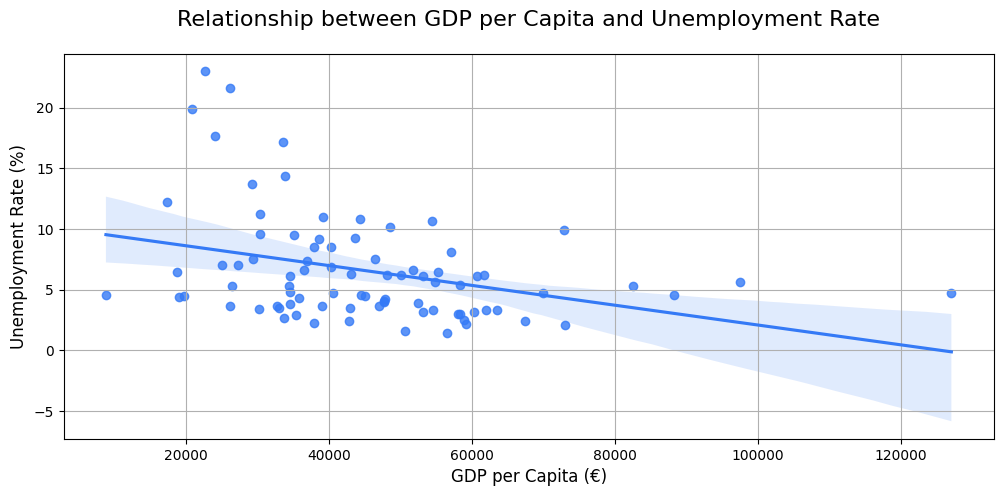

In [47]:
plt.figure(figsize=(12, 5))
#regplot includes the regression line
sns.regplot(x=dataset['GDP per Capita (€)'], y=dataset['Unemployment Rate'], color = '#357AF6')
plt.grid(True)
plt.title('Relationship between GDP per Capita and Unemployment Rate', fontsize=16, pad=20)
plt.xlabel('GDP per Capita (€)', fontsize=12)
plt.ylabel('Unemployment Rate (%)', fontsize=12)

plt.show()

##### **Explanation**

The scatter plot illustrates the relationship between `GDP per Capita (€)` and the `Unemployment Rate (%)`. Each blue dot represents a record of a country and they show the distribution for both variables, with GDP per Capita ranging from approximately 15,000€ to over 120,000€, and the Unemployment Rate from lows of around 2% to extreme highs exceeding 20%.


Surrounding the blue line, there's this blue shaded area which represents the **confidence interval**, an important statistical component. This shadow does not represent the data points themselves, but rather the **uncertainty** in the line's prediction. Essentially, it shows the precision of the estimated relationship. Where the shadow is narrower (in the middle of the data cluster), the predicted relationship is **more precise**, where the shadow is wider (particularly at the extremes of the GDP per Capita axis), there is greater uncertainty in predicting the Unemployment Rate.

The most significant finding in this graph is the clear **negative relationship** between these two features, as we can visualise by the downward-sloping regression line. This means that as the **GDP per Capita increases, Unemployment Rate tends to decrease**. Therefore, countries with lower levels of GDP per capita tend to struggle with higher rates of unemployment.

We can also notice the presence of some outliers, the data points lying far outside of the confidence interval. The most notable ones involve countries with moderate GDP per Capita (€20,000 - €40,000) that have an exceptionally high unemployment rate (above 15%). These records highlight that the GDP per Capita variable is not sufficient to explain the distribution of the unemployment rate in all cases.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.b) Which are the top 5 cities with the largest difference between the Average Monthly Salary and Average Cost of Living? What about the top 5 countries with the smallest average difference? Show these results with meaningful visualizations.**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
In this question we had two possible intrepretations: 
- Firstly we calculated the absolute value of the difference between Average Monthly Salary and Average Cost of Living, to be the same as doing `Average Monthly Salary (€)` - `Average Cost of Living` or the contrary.
  
- But to understand the real intrepretation we calculated the difference without the absolute value. 

In [48]:
salary_below_cost = dataset[dataset['Average Monthly Salary (€)'] < dataset['Average Cost of Living']]
salary_below_cost 

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country
City,,,,,,,,,,,,,
London,1777,12396541,8274794,29.1,6.1,60780.81,0,"English, Urdu, Bengali, Polish",2750,1900,2800,2023-04-09,United Kingdom
Athens,1829,3530371,2287174,22.0,17.2,33564.60,17,"Greek, English",1050,600,1200,2024-07-16,Greece
Thessaloniki,381,1050568,684564,22.2,19.9,20827.80,10,Greek,1000,550,1100,2023-12-21,Greece
Venice,852,557748,347781,19.3,6.1,34522.47,6,Italian,1400,1150,1500,2023-03-23,Italy
Cracow,376,1410424,938323,23.7,2.9,35427.27,0,"Polish, English",1400,1000,1500,2023-07-11,Poland
Lisbon,695,3008000,1871604,25.4,7.4,36855.81,1,"Portuguese, English",1220,1050,1600,2024-10-04,Portugal
Porto,1343,1280190,840851,20.5,7.0,27264.93,0,Portuguese,1100,900,1400,2023-05-23,Portugal
Braga,501,247719,169611,20.3,7.0,25041.21,1,Portuguese,1000,700,1100,2024-01-31,Portugal
Coimbra,162,264656,166311,19.5,5.3,26454.09,2,Portuguese,1000,650,1050,2024-06-19,Portugal


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
As we can see above, we have cities where the difference between Average Monthly Salary (€) and Average Cost of Living is negative, which means that the population observed is spending more that it recives. (just to be sure it exists the negative option).

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**First question:**
    

Absolute Value: 

In [49]:
# here we will answer the first question
difference = (dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']).abs()  # absolute difference
sorted_difference = difference.sort_values(ascending=False)  # sorts in descending order
top_5_cities = sorted_difference.head().index.tolist() #sortes the value in a desceding way. we now have the highest differences on head and the lowest on the tail

print(f'Answer 1: The top 5 cities with the largest absolute difference between the Average Monthly Salary and the Average Cost of Living are {", ".join(top_5_cities)}.')


Answer 1: The top 5 cities with the largest absolute difference between the Average Monthly Salary and the Average Cost of Living are Basel, Tampere, Helsinki, Zurich, Geneva.


Not Absolute Value: 

In [50]:
# here we will answer the first question
difference = dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']  # absolute difference
sorted_difference = difference.sort_values(ascending=False)  # sorts in descending order
top_5_cities = sorted_difference.head().index.tolist() #sortes the value in a desceding way. we now have the highest differences on head and the lowest on the tail

print(f'Answer 1: The top 5 cities with the largest difference (negative or positive) between the Average Monthly Salary and the Average Cost of Living are {", ".join(top_5_cities)}.')


Answer 1: The top 5 cities with the largest difference (negative or positive) between the Average Monthly Salary and the Average Cost of Living are Basel, Tampere, Helsinki, Zurich, Geneva.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Since both the absolute and signed difference analyses yield the same top five cities, this indicates that these cities consistently exhibit positive salary–cost gaps. Therefore, they can be interpreted as offering higher relative purchasing power compared to other cities in the dataset.**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
Plot for both: 

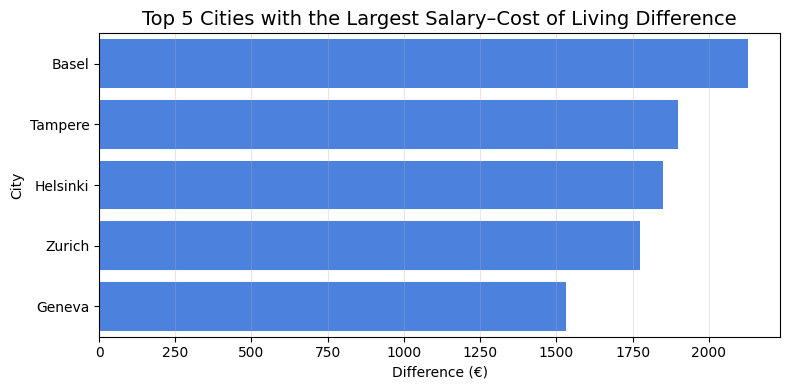

In [51]:
# Plot
dataset['Difference (€)'] = dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']

# Top 5 cities
top_5_cities = dataset['Difference (€)'].sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=top_5_cities.values,   # Difference on x-axis
    y=top_5_cities.index,    # City names on y-axis
    orient='h',
    color='#357AF6'
)

plt.title('Top 5 Cities with the Largest Salary–Cost of Living Difference', fontsize=14)
plt.xlabel('Difference (€)')
plt.ylabel('City')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Second question:**
    

Absolute Value: 

In [52]:
dataset['Difference (€)'] = (dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']).abs()
country_avg_difference = dataset.groupby('Country')['Difference (€)'].mean()
country_avg_difference_sorted = country_avg_difference.sort_values(ascending = True)
top_5_countries = country_avg_difference_sorted.head().index.tolist()

print(f'Answer 2: The top 5 countries with the smallest average absolute difference between the Average Monthly Salary and the Average Cost of Living are {','.join(top_5_countries)}.')

Answer 2: The top 5 countries with the smallest average absolute difference between the Average Monthly Salary and the Average Cost of Living are  Romania, Turkiye, Latvia, Malta, Slovenia.


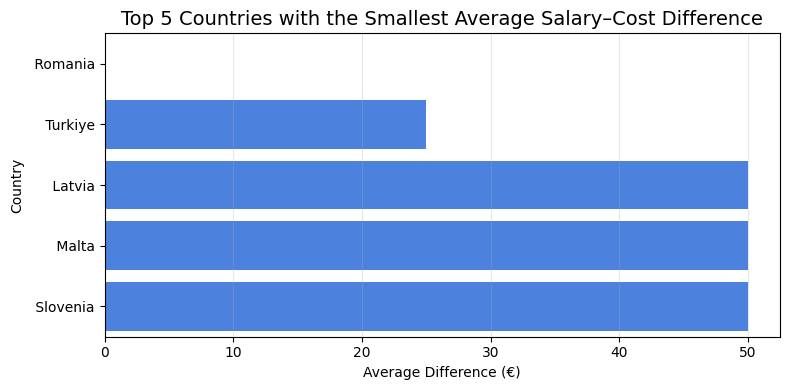

In [53]:
# Average difference per country
country_avg_difference = (
    dataset.groupby('Country')['Difference (€)']
    .mean()
    .sort_values()
    .head(5)
)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=country_avg_difference.values,
    y=country_avg_difference.index,
    color='#357AF6'
)

plt.title('Top 5 Countries with the Smallest Average Salary–Cost Difference', fontsize=14)
plt.xlabel('Average Difference (€)')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Not Absolute Value:

In [54]:
dataset['Difference (€)'] = dataset['Average Monthly Salary (€)'] - dataset['Average Cost of Living']
country_avg_difference = dataset.groupby('Country')['Difference (€)'].mean()
country_avg_difference_sorted = country_avg_difference.sort_values(ascending = True)
top_5_countries = country_avg_difference_sorted.head().index.tolist()

print(f'Answer 2: The top 5 countries with the smallest average difference between the Average Monthly Salary and the Average Cost of Living are {','.join(top_5_countries)}.')

Answer 2: The top 5 countries with the smallest average difference between the Average Monthly Salary and the Average Cost of Living are  Portugal, Greece, Slovak Republic, Turkiye, Poland.


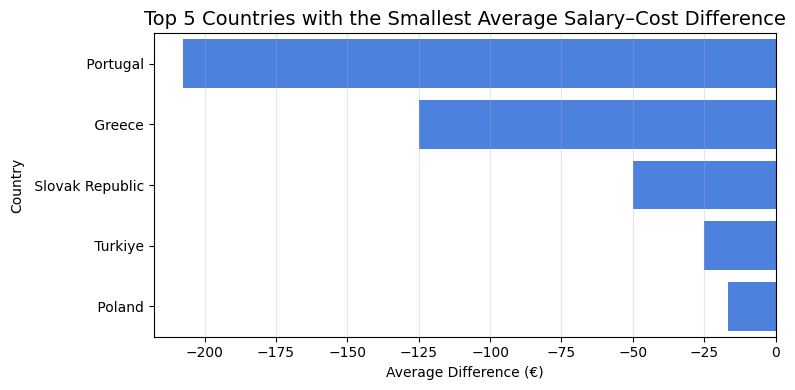

In [55]:
# Average difference per country
country_avg_difference = (
    dataset.groupby('Country')['Difference (€)']
    .mean()
    .sort_values()
    .head(5)
)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=country_avg_difference.values,
    y=country_avg_difference.index,
    color='#357AF6'
)

plt.title('Top 5 Countries with the Smallest Average Salary–Cost Difference', fontsize=14)
plt.xlabel('Average Difference (€)')
plt.ylabel('Country')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Insights:**
\
The comparison between the **absolute and non-absolute** salary–cost differences leads to different sets of countries, highlighting that these two measures capture distinct economic realities. 

When using the **absolute difference,** the countries identified (e.g., Romania, Türkiye, Latvia, Malta, and Slovenia) are those where average salaries and costs of living are very close in magnitude, regardless of whether salaries are higher or lower than costs. This indicates tight financial margins, where small changes in income or expenses could significantly affect living conditions.

In contrast, when using the **non-absolute (signed) difference,** the countries identified (e.g., Portugal, Greece, Slovak Republic, Türkiye, and Poland) are those where salaries are on average lower than or only slightly above the cost of living, reflecting structural affordability pressure rather than balance. This measure preserves the direction of the difference and is therefore more informative for assessing economic vulnerability and purchasing power.

Overall, the **divergence between the two results shows that absolute differences are useful for identifying balance, while non-absolute differences are more appropriate for evaluating affordability and economic strain.** Consequently, the interpretation depends on the analytical objective, and both perspectives provide complementary insights into living conditions across European countries.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**3.c) Which is the best city for someone seeking:**
- an average monthly salary above €1600,
- a cost of living below €900, and
- a country suitable for starting a family (with a relatively larger youth population)?

We have one variable called `Youth Dependancy Ratio`that can helps us with the last topic (country with relatively larger youth population). We started to group the countries by the average of the young dependency ratio in the corresponding cities. \
As one of the requests is the city being in a country with a relatively larger population, we sorted that list and found the top 20 countries with the highest youth dependency ratio.

After analyzing many combinations, we concluded that **no city in our dataset meets all three initial conditions simultaneously**. This is likely because the requirement for a high salary (>1600€) and a very low cost of living (>900€) is mutually exclusive in most real-world economies. Therefore, we tried to find a realistic alternative: cities with the requested high salary (>1600€), located in a top 20 youth-populated country (using the top20_larger_youth_country variable), and then, ranked these results by the lowest cost of living to identify the best practical balance.

c:\Users\tiago\anaconda3\envs\PDS_environment\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


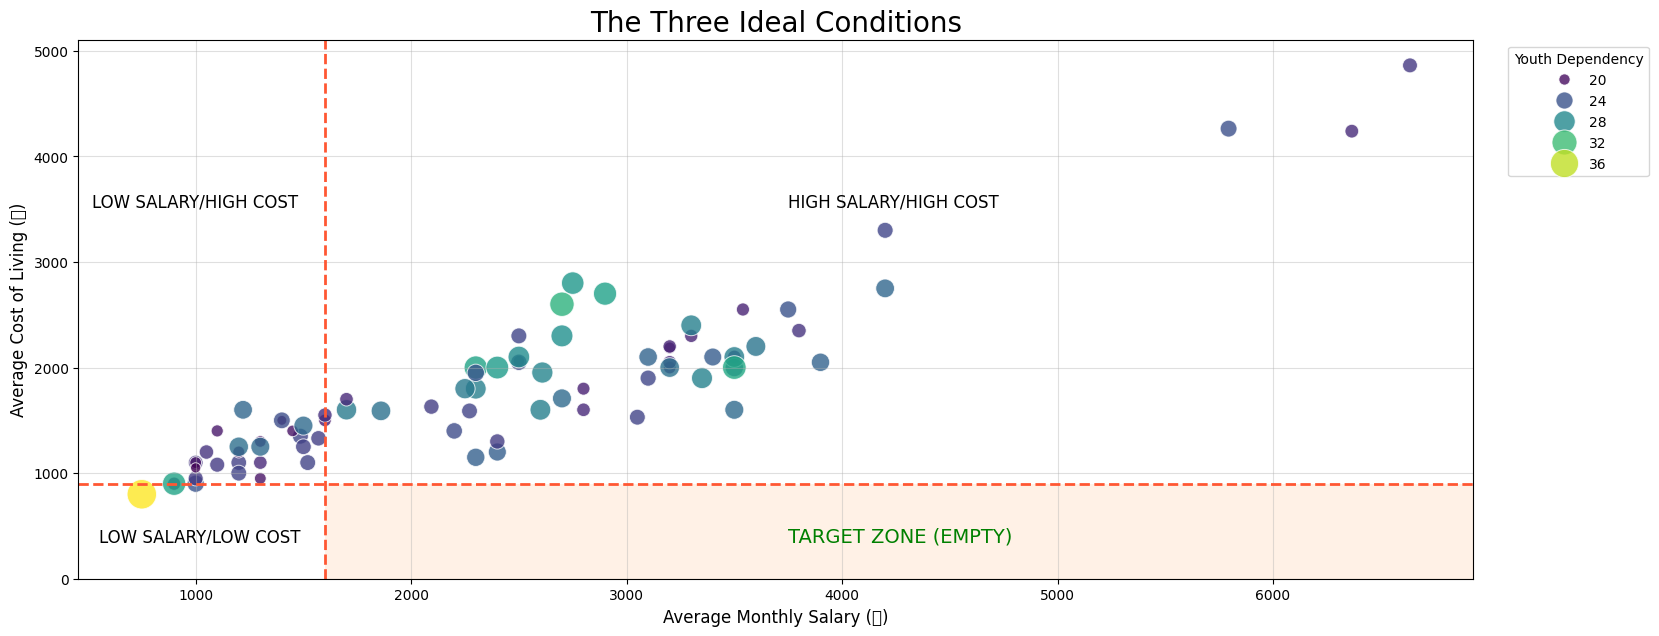

In [56]:
#define the columns to be used
x_col = 'Average Monthly Salary (€)'
y_col = 'Average Cost of Living'
z_col = 'Youth Dependency Ratio' # The 3rd condition (Color)
# Thresholds
min_salary = 1600
max_cost = 900
plt.figure(figsize=(18, 7))
sns.scatterplot(
    data=dataset, x=x_col, y=y_col, hue=z_col, size=z_col,sizes=(50, 450), palette='viridis', alpha=0.8)
# vertical Line (income threshold)
plt.axvline(x=min_salary, color='#FF5733', linestyle='--', linewidth=2)
# Horizontal Line (cost threshold)
plt.axhline(y=max_cost, color='#FF5733', linestyle='--', linewidth=2)
#target zone that meets the 3 conditions
x_limits = plt.xlim()
y_limits = plt.ylim()
#this paints that area
plt.fill_between([min_salary, x_limits[1]], 0, max_cost, alpha=0.1)
#texts 
plt.text(3750, 3520, "HIGH SALARY/HIGH COST", fontsize=12)
plt.text(520, 3520, "LOW SALARY/HIGH COST", fontsize=12)
plt.text(550, 350, "LOW SALARY/LOW COST",fontsize=12)
plt.text(3750,350, "TARGET ZONE (EMPTY)", fontsize=14, color='green')

plt.title('The Three Ideal Conditions', fontsize=20)
plt.xlabel('Average Monthly Salary ()', fontsize=12)
plt.ylabel('Average Cost of Living ()', fontsize=12)
plt.ylim(bottom=0) # Start y at 0 to cause it needs to be logical
plt.xlim(x_limits) #restore limits
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Youth Dependency")
plt.grid(True, alpha=0.4)
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

The visualization above was created so we could have **visual proof** that does **not exist** a city in our dataset that meets the conditions defined.

**Observations**:
- **The Target Empty Zone**: As evidenced by the shaded region in the bottom-right quadrant, **no data points fall within the target zone**. The area representing high salaries and low costs is completely empty.
- **The Explanation**: The scatter plot reveals a **strong positive correlation between Salary and Cost of Living**. As average salaries increase, the cost of living also increases in the majority of the cities. This reality makes the coexistence of high salaries and very low costs **impossible** in this dataset.
- **Conclusion & Recommendation**: As there's no city which satisfies all three conditions simultaneously, we must look for the cities that sit closest to the target zone borders. Therefore, we tried to find a **realistic alternative**: cities with the requested high salary (>1600€), located in a top 10 youth-populated country (using the top10_larger_youth_country variable), and then, ranked these results by the lowest cost of living to identify the best practical balance.

In [57]:
larger_youth_country = dataset.groupby('Country')['Youth Dependency Ratio'].mean()
sorted_larger_youth_country = larger_youth_country.sort_values(ascending= False)
top10_larger_youth_country = sorted_larger_youth_country[:10]
top_countries_names = top10_larger_youth_country.index

In [58]:
filtered = dataset['Country'].isin(top_countries_names) #checks if the country of each city in the dataframe is in that list of the top 

In [59]:
best_city = ((dataset['Average Monthly Salary (€)'] > 1600)& (filtered))
best_city_found = dataset[best_city].iloc[:5]

In [60]:
best_city_found_sorted = best_city_found.sort_values(
    by='Average Cost of Living', 
    ascending=True
)
best_city_found_sorted

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€)
City,,,,,,,,,,,,,,
Gent,552,645813,417832,24.80,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200
Tallinn,2469,390860,253977,26.90,3.5,42916.23,0,"Estonian, Russian, English",1700,700,1600,2023-08-23,Estonia,100
Bruges,840,119765,74600,25.63,5.6,54882.21,0,"Dutch, French",2700,1250,1708,2023-10-25,Belgium,992
Brussels,681,3284548,2137425,27.50,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,Belgium,1450
Antwerp,928,1139663,723396,27.70,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,Belgium,656


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**Our Suggestion**
- We **isolated the Top 10 Countries** with the youngest populations (highest Youth Dependency Ratio) to ensure we meet the "a country suitable for starting a family (with a relatively larger youth population)"
- Within this subset, we filtered for **salaries above 1600€** to ensure financial stability.
- Finally, we **sorted by lowest cost of living** to maximize efficiency.
**The Final Decision**: Based on this algorithm, the city at the top of the dataframe - **Ghent, Belgium** - represents the "almost perfect" choice. It is the cheapest possible average cost of living, in a city located in the top 10 countries with a young population and maintainh a salary above 1600€.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**4.What are three additional insights you find meaningful when comparing the given cities?**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
1. Which cities have the highest purchasing power ratio (salary relative to cost of living)?

In [61]:
dataset['Purchasing Power Ratio'] = (
    dataset['Average Monthly Salary (€)'] /
    dataset['Average Cost of Living'])

top_5_pp = dataset['Purchasing Power Ratio'].sort_values(ascending=False).head(5)

top_5_pp

City
Tampere     2.187500
Gent        2.000000
Seville     2.000000
Dresden     1.993464
Helsinki    1.902439
Name: Purchasing Power Ratio, dtype: float64

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
The results show that cities such as **Tampere, Gent, Seville, Dresden, and Helsinki** have the highest purchasing power ratios, meaning that **average salaries in these cities are close to, or more than double, the cost of living.** This indicates that residents in these cities are able to retain a larger proportion of their income after covering essential expenses. Importantly, this insight demonstrates that high quality of life is not exclusively associated with the highest salaries, but rather with a favorable balance between income and living costs.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
2. Do larger cities tend to have higher costs of living?

In [62]:
corr = dataset['GDP per Capita (€)'].corr(dataset['Unemployment Rate'])
print(f"Correlation between GDP per capita and unemployment rate: {corr:.2f}")


Correlation between GDP per capita and unemployment rate: -0.35


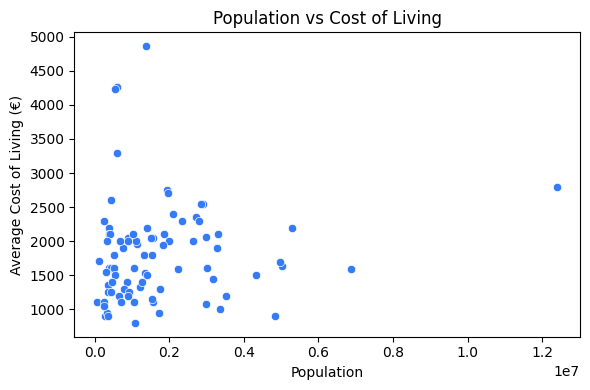

In [63]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=dataset['Population'],
    y=dataset['Average Cost of Living'],
    color='#357AF6'
)
plt.title('Population vs Cost of Living')
plt.xlabel('Population')
plt.ylabel('Average Cost of Living (€)')
plt.tight_layout()
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

The correlation between GDP per capita and unemployment rate is moderately negative (-0.35), suggesting that cities with higher economic output per capita tend to have lower unemployment levels. This indicates that stronger local economies are generally associated with better labor market conditions. However, the relationship is not strong enough to be deterministic, implying that unemployment is also influenced by structural, social, and regional factors beyond economic wealth alone.

At the same time, the scatter plot shows that population size is not a reliable predictor of cost of living, as both small and large cities exhibit a wide range of living costs. This reinforces the idea that economic conditions and policy context matter more than city size when evaluating living affordability.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
3. Which cities combine low unemployment with high purchasing power?

In [64]:
dataset['Purchasing Power Ratio'] = (
    dataset['Average Monthly Salary (€)'] /
    dataset['Average Cost of Living']
)

best_balance = dataset[
    (dataset['Unemployment Rate'] < dataset['Unemployment Rate'].median()) &
    (dataset['Purchasing Power Ratio'] > dataset['Purchasing Power Ratio'].median())
]

best_balance[['Country', 'Unemployment Rate', 'Purchasing Power Ratio']].head()


,Country,Unemployment Rate,Purchasing Power Ratio
City,,,
Salzburg,Austria,3.0,1.463861
Zurich,Switzerland,4.7,1.364870
Ostrava,Czechia,3.7,1.381818
Berlin,Germany,4.7,1.454545
Hamburg,Germany,3.2,1.666667


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
Insight: 
    
The results identify cities such as Salzburg, Zurich, Ostrava, Berlin, and Hamburg as locations that successfully combine low unemployment rates with high purchasing power. This indicates that these cities offer not only strong labor market conditions but also favorable economic balance, allowing residents to retain a substantial portion of their income after living expenses. From a quality-of-life perspective, these cities represent particularly attractive options, as they balance job stability and financial well-being, two key factors for individuals deciding where to live.

<div style="background-color:#357AF6; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>3. Working with Advanced Topics</b></h3>
    
**Building an Interactive Map**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
The goal of this section is to create an interactive map of Europe where users can explore cities and view relevant information such as country, population, average salary, and cost of living. This task is divided into two main parts: **3.1 Web Scraping** and **3.2 Interative Map**


In [65]:
dataset.index

Index(['Vienna', 'Salzburg', 'Brussels', 'Antwerp', 'Gent', 'Bruges', 'Sofia',
       'Dobrich', 'Zurich', 'Geneva', 'Basel', 'Lefkosia', 'Lemesos', 'Prague',
       'Ostrava', 'Berlin', 'Hamburg', 'Munich', 'Cologne',
       'Frankfurt am Main', 'Stuttgart', 'Leipzig', 'Dresden', 'Dusseldorf',
       'Hanover', 'Copenhagen', 'Odense', 'Madrid', 'Barcelona', 'Valencia',
       'Seville', 'Malaga', 'Tallinn', 'Helsinki', 'Tampere', 'Paris', 'Lyon',
       'Toulouse', 'London', 'Leeds', 'Glasgow', 'Liverpool', 'Edinburgh',
       'Athens', 'Thessaloniki', 'Zagreb', 'Split', 'Budapest', 'Miskolc',
       'Debrecen', 'Dublin', 'Cork', 'Rome', 'Milan', 'Naples', 'Turin',
       'Florence', 'Venice', 'Luxembourg', 'Riga', 'Malta', 'The Hague',
       'Amsterdam', 'Rotterdam', 'Utrecht', 'Eindhoven', 'Oslo', 'Bergen',
       'Stavanger', 'Warsaw', 'Lodz', 'Cracow', 'Lisbon', 'Porto', 'Braga',
       'Coimbra', 'Giroc', 'Bratislava', 'Ljubljana', 'Stockholm',
       'Gothenburg', 'Malmo', 'Ank

In [66]:
dataset.rename(index = {'Gent': 'Ghent', 'Lefkosia': 'Nicosia', 'Lemesos': 'Limassol' }, inplace = True)
dataset.index
dataset.loc[['Ghent']]

,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€),Purchasing Power Ratio
City,,,,,,,,,,,,,,,
Ghent,552,645813,417832,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200,2.0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h4><b>3.1 Web Scraping</b></h4>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 


**Geographical Coordinates**

In order to build an interactive geographical visualization of European cities, it was necessary to obtain accurate latitude and longitude coordinates for each city in the dataset. Since this information was not directly available in the original data, a web scraping approach was used to extract the geographical coordinates from Wikipedia. This step ensures that each city is correctly located on the map, enabling a reliable spatial analysis and supporting the advanced topic requirements of the project.

In [67]:
# initialize Chrome driver with default options
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(options = options)
wait = WebDriverWait(driver, 5)
# list to store the scraped results
list_of_coordinates = []


# iterate through each row in the dataset to process cities one by one
for index, row in dataset.iterrows():


    # clean and prepare city and country names for the search
    city_raw = str(index) if index else str(row.name)

    # remove commas and semicolons to get the "pure" city name
    clean_city = city_raw.split(',')[0].split(';')[0].strip()
    country = row['Country'].strip() 
    #wikipedia uses "Turkey" instead of "Turkiye"
    if country == 'Turkiye':
        country = 'Turkey'

    if clean_city in ['Giroc', 'Malta','Ostrava']: #these 3 cities only work without the country name
        query = clean_city
    else:
        query = f"{clean_city}, {country}" #the standard is almost always city, country

    search_url = f"https://en.wikipedia.org/w/index.php?search={query}&title=Special:Search&go=Go"
    
    try:
        driver.get(search_url)
        try: #attempt to find coordinates
            coord_element = wait.until(EC.presence_of_element_located((By.CLASS_NAME, 'geo-dec')))
            coords = coord_element.get_attribute('textContent').strip()
            
            if not coords:
                coord_element = driver.find_element(By.CLASS_NAME, 'geo-default')
                coords = coord_element.get_attribute('textContent').strip()
                
            print(f'{clean_city}: {coords}')
            list_of_coordinates.append({'City': clean_city,'Coordinates': coords})
        
        except: #backup attempt with different class names
            try:
                coord_element = driver.find_element(By.CLASS_NAME, 'geo')
                coords = coord_element.get_attribute('textContent').strip()
                print(f'{clean_city} (backup): {coords}')
                list_of_coordinates.append({'City': clean_city, 'Coordinates': coords})
            except: #if all attempts fail
                print(f'{clean_city}: Coordinates not found (Page might be ambiguous)')
                list_of_coordinates.append({'City': clean_city, 'Coordinates': None})

    except Exception as e: #catch any other errors
        print(f'Error scraping {clean_city}: {e}')
        list_of_coordinates.append({'City': clean_city, 'Coordinates': None})

driver.quit()

Vienna: 48.20833°N 16.37250°E
Salzburg: 47.80000°N 13.04500°E
Brussels: 50.84667°N 4.35250°E
Antwerp: 51.21778°N 4.40028°E
Ghent: 51.05361°N 3.72528°E
Bruges: 51.20889°N 3.22417°E
Sofia: 42.70°N 23.33°E
Dobrich: 43.567°N 27.833°E
Zurich: 47.37444°N 8.54111°E
Geneva: 46.20167°N 6.14694°E
Basel: 47.55472°N 7.59056°E
Nicosia: 35.17250°N 33.36500°E
Limassol: 34.67472°N 33.04417°E
Prague: 50.08750°N 14.42139°E
Ostrava: 49.83556°N 18.29250°E
Berlin: 52.52000°N 13.40500°E
Hamburg: 53.550°N 10.000°E
Munich: 48.13750°N 11.57500°E
Cologne: 50.93639°N 6.95278°E
Frankfurt am Main: 50.11056°N 8.68222°E
Stuttgart: 48.77750°N 9.18000°E
Leipzig: 51.34000°N 12.37500°E
Dresden: 51.05000°N 13.74000°E
Dusseldorf: 51.22556°N 6.77667°E
Hanover: 52.367°N 9.717°E
Copenhagen: 55.67611°N 12.56833°E
Odense: 55.39583°N 10.38861°E
Madrid: 40.500°N 3.667°W
Barcelona: 41.383°N 2.183°E
Valencia: 39.47000°N 0.37639°W
Seville: 37.39000°N 5.99000°W
Malaga: 36.71944°N 4.42000°W
Tallinn: 59.43722°N 24.74528°E
Helsinki: 60

In [68]:
list_of_coordinates 

[{'City': 'Vienna', 'Coordinates': '48.20833°N 16.37250°E'},
 {'City': 'Salzburg', 'Coordinates': '47.80000°N 13.04500°E'},
 {'City': 'Brussels', 'Coordinates': '50.84667°N 4.35250°E'},
 {'City': 'Antwerp', 'Coordinates': '51.21778°N 4.40028°E'},
 {'City': 'Ghent', 'Coordinates': '51.05361°N 3.72528°E'},
 {'City': 'Bruges', 'Coordinates': '51.20889°N 3.22417°E'},
 {'City': 'Sofia', 'Coordinates': '42.70°N 23.33°E'},
 {'City': 'Dobrich', 'Coordinates': '43.567°N 27.833°E'},
 {'City': 'Zurich', 'Coordinates': '47.37444°N 8.54111°E'},
 {'City': 'Geneva', 'Coordinates': '46.20167°N 6.14694°E'},
 {'City': 'Basel', 'Coordinates': '47.55472°N 7.59056°E'},
 {'City': 'Nicosia', 'Coordinates': '35.17250°N 33.36500°E'},
 {'City': 'Limassol', 'Coordinates': '34.67472°N 33.04417°E'},
 {'City': 'Prague', 'Coordinates': '50.08750°N 14.42139°E'},
 {'City': 'Ostrava', 'Coordinates': '49.83556°N 18.29250°E'},
 {'City': 'Berlin', 'Coordinates': '52.52000°N 13.40500°E'},
 {'City': 'Hamburg', 'Coordinates'

In [69]:
dataset = dataset.reset_index()
dataset.head()

,City,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€),Purchasing Power Ratio
0,Vienna,310,2983513,2018818,20.1,10.2,48519.90,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15,Austria,439,1.213003
1,Salzburg,243,375489,250472,20.3,3.0,58019.43,0,German,3200,1100,2186,2023-11-03,Austria,1014,1.463861
2,Brussels,681,3284548,2137425,27.5,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,Belgium,1450,1.763158
3,Antwerp,928,1139663,723396,27.7,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,Belgium,656,1.335893
4,Ghent,552,645813,417832,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200,2.000000


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h4><b>3.2 Interative Map</b></h4>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">

Using the geographical coordinates obtained through web scraping, an interactive map of Europe was created to visually explore and compare cities across different countries. The map allows users to interact with each city and access key information such as country, population, average monthly salary, and cost of living. This interactive visualization enhances the analytical component of the project by transforming numerical data into an intuitive and user-friendly tool, directly supporting informed decision-making about where to live.

In [70]:
coordenates_dataset = pd.DataFrame(list_of_coordinates)



def extract_coordenates(coord):
    latitude = re.search(r'([\d.]+)°\s*[NS]', coord)
    longitude = re.search(r'([\d.]+)°\s*[EW]', coord)

    if latitude and longitude:
        latitude = float(latitude.group(1))
        longitude = float(longitude.group(1))
        if 'S' in coord:
            latitude = -latitude
        if 'W' in coord:
            longitude = -longitude
        return latitude, longitude
    return None, None

dataset[['Latitude', 'Longitude']] = coordenates_dataset['Coordinates'].apply(lambda x: pd.Series(extract_coordenates(x)))
dataset.head()

,City,Population Density (/km2),Population,Working Age Population (15-64 years),Youth Dependency Ratio,Unemployment Rate,GDP per Capita (€),Days of very strong heat stress (>38ºC),Main Spoken Languages,Average Monthly Salary (€),Average Rent Price (€),Average Cost of Living,Last Data Update,Country,Difference (€),Purchasing Power Ratio,Latitude,Longitude
0,Vienna,310,2983513,2018818,20.1,10.2,48519.90,3,"German, English, Turkish, Serbian",2500,1050,2061,2024-06-15,Austria,439,1.213003,48.20833,16.37250
1,Salzburg,243,375489,250472,20.3,3.0,58019.43,0,German,3200,1100,2186,2023-11-03,Austria,1014,1.463861,47.80000,13.04500
2,Brussels,681,3284548,2137425,27.5,10.7,54375.00,3,"French, Dutch, Arabic, English",3350,1200,1900,2023-04-22,Belgium,1450,1.763158,50.84667,4.35250
3,Antwerp,928,1139663,723396,27.7,6.2,50107.65,3,"Dutch, French, Arabic",2609,900,1953,2024-08-09,Belgium,656,1.335893,51.21778,4.40028
4,Ghent,552,645813,417832,24.8,7.5,46380.57,2,"Dutch, French",2400,827,1200,2023-07-17,Belgium,1200,2.000000,51.05361,3.72528


In [71]:
"""
Interactive Map Visualization
=============================
This section uses Plotly to generate an interactive map of the scraped cities.
It visualizes the geographic distribution and provides detailed data (Salary, 
Cost, Population) via hover tooltips.
"""
# data cleaning for plotting
# makes sure all values are numeric
# errors='coerce' turns non-numeric values into NaN, which we then drop
numeric_columns = ['Population','Average Monthly Salary (€)','Average Cost of Living','Latitude','Longitude']
for col in numeric_columns:
    dataset[col] = pd.to_numeric(dataset[col], errors = 'coerce')
#drop the cities where we couldn´t find
dataset = dataset.dropna(subset = ['Latitude', 'Longitude'])
#prepare Hover text
dataset['hover_text'] = (
    '<b>' + dataset['City'] + '</b><br>' +
    'Country: ' + dataset['Country'] + '<br>' +
    'Population: ' + dataset['Population'].astype(int).astype(str) + '<br>' +
    'Average Monthly Salary: ' + dataset['Average Monthly Salary (€)'].astype(int).astype(str) + '<br>' +
    'Average Cost of Living: ' + dataset['Average Cost of Living'].astype(int).astype(str))
#creating a interative map
fig = go.Figure(go.Scattergeo(
    lon = dataset['Longitude'],
    lat = dataset['Latitude'],
    hovertext = dataset['hover_text'],
    hoverinfo = 'text',
    mode = 'markers+text',
    text = dataset['City'],          
    textposition = 'top center',
    marker = dict(size = 8, color = 'royalblue', line = dict(width = 0.5, color = 'black'))))

fig.update_layout(
    title = 'Interactive Map of European Cities',
    width = 1600,  
    height = 700,
    geo = dict(
        scope = 'world', ##once again, use world instead of europe to include turkey and cyprus
        center = dict(lat=50, lon=10),
        projection_type = 'natural earth',
        showland = True,
        landcolor = 'rgb(240, 240, 240)',
        showcountries = True,
        countrycolor = 'rgb(200, 200, 200)'), margin = dict(l = 10, r = 10, t = 50, b = 10))

fig.show()
#fig.write_html("interactive_europe_map.html")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h4><b>3.3 Observation of Web Scraping and Interactive Map</b></h4>

We had several problems while coding these two parts. In this section, we are going to explain those challenges and how we handled them.

- **Ambiguous Common Names**: 

Cities with names that are also common English words, such as Split (Croatia) or Cork (Ireland),redirected to definitions like the verb "to split" or the material "cork". We solved this by appending the country name to the search query ("Split, Croatia"), which successfully directed to the correct city pages. 

- **Search Exception Handling**: However, applying the standard "City, Country" format caused errors for specific locations, requiring a targeted approach:

    - **Malta**: Searching for "Malta, Malta" incorrectly redirected to a small village in Lithuania. We adjusted the script to search simply for "Malta" to find the island nation.
    - **Giroc & Ostrava**: Searching for "Giroc, Romania" returned no results due to specific indexing on Wikipedia. These were resolved by searching for the city name alone.

- **Country Naming Mismatches**: 

The dataset uses "Turkiye", whereas English Wikipedia indexes the country as "Turkey". We manually added a string replacement rule to ensure successful redirects for Turkish cities.

- **Coordinate Formatting**: 

Wikipedia stores coordinates in multiple formats. Our script utilizes a try-except block to iterate through these classes, extracting the textContent even when hidden from the UI.

- **Geographical Anomalies ("Cities in the Ocean")**: 

Initially, some cities (Nicosia, Limassol, Ankara) appeared in the middle of the ocean due to inverted Latitude/Longitude or specific scraping errors.
We verified these coordinates and, given that some territories (like Cyprus or parts of Turkey) are geographically on the edge of the standard "Europe" projection, we changed the visualization to a World Map instead. This ensures no data points are "in the middle of the ocean", providing a complete view of the dataset. To provide a better visualization of the European Cities, it is possible to zoom in or zoom out the map. 

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b>4. Data Science in Action: Framework and Conclusions</b></h3>


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

In this final phase, for the **"Data Science in Action"**, we decided to treat more than just static analysis and **create a dynamic tool** that adapts to the **user's needs**. We developed an algorithm that begins by asking the user's age and monthly income as inputs. While these inputs might seem simple, they are extremely important: they allow us to automatically "categorize" the user into one of **six  profiles** that we established beforehand.

\
The main idea behind this profiling is the context and the specific characteristics of each individual. We established ,for each category, the most interesting possible topics for the different ages and monthly incomes.
 We understand that a 20-year-old student has very different priorities compared to a 50-year-old executive. Therefore, once the user is categorized, the algorithm presents the user a list of the four most relevant variables specifically tailored to their profile's interests.
From this selection, the user chooses a **primary topic**. We then implemented a feature that lets the user combine this first choice with a second variable. If a combination is selected, our code generates a "new combo variable", a  metric with a meaning designed to offer richer insights than a single variable could providing alone.

\
Finally, the results are presented visually to ensure clarity. Whether the user analyzes a single metric or a combined one, the system outputs the Top 5 best and worst cities for that specific criteria, alongside an interactive Heatmap. This approach empowers the user to visualize patterns across Europe instantly, turning raw data into a personalized recommendation system.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h4><b>4.1 Correlation between columns of the dataset</b></h4>
For a better understanding of our dataset variables and which of them relate better, the following heatmap creates a good visualization for this task.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
`hover_text` is an **irrelevant column** so we will just **drop it.**

In [72]:
dataset.drop('hover_text', axis = 1, inplace = True)

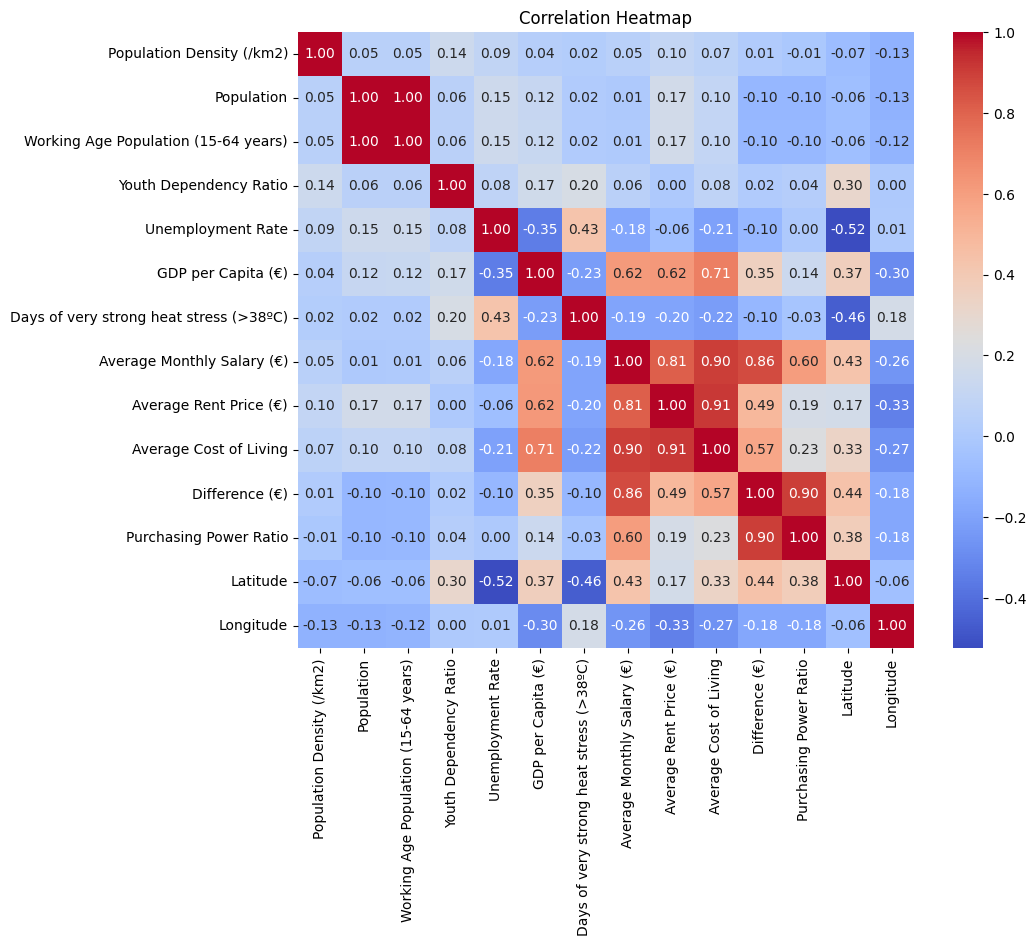

In [73]:
corr_matrix = dataset.corr(numeric_only = True)
plt.figure(figsize = (10, 8))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', square = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

**From the analysis of this heatmap we can observe that:**
* **1.0 (Dark Red):** Perfect Positive Correlation. When one goes up, the other goes up.
* **-1.0 (Dark Blue):** Perfect Negative Correlation. When one goes up, the other goes down.
* **(White/Light):** No relationship. The variables are independent.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
Since only a high correlation between variables might interest to the user, we created another heatmap with a threshold of 0,55 (a value that we assumed as a minimum for the columns to have a significant relation between each other). 

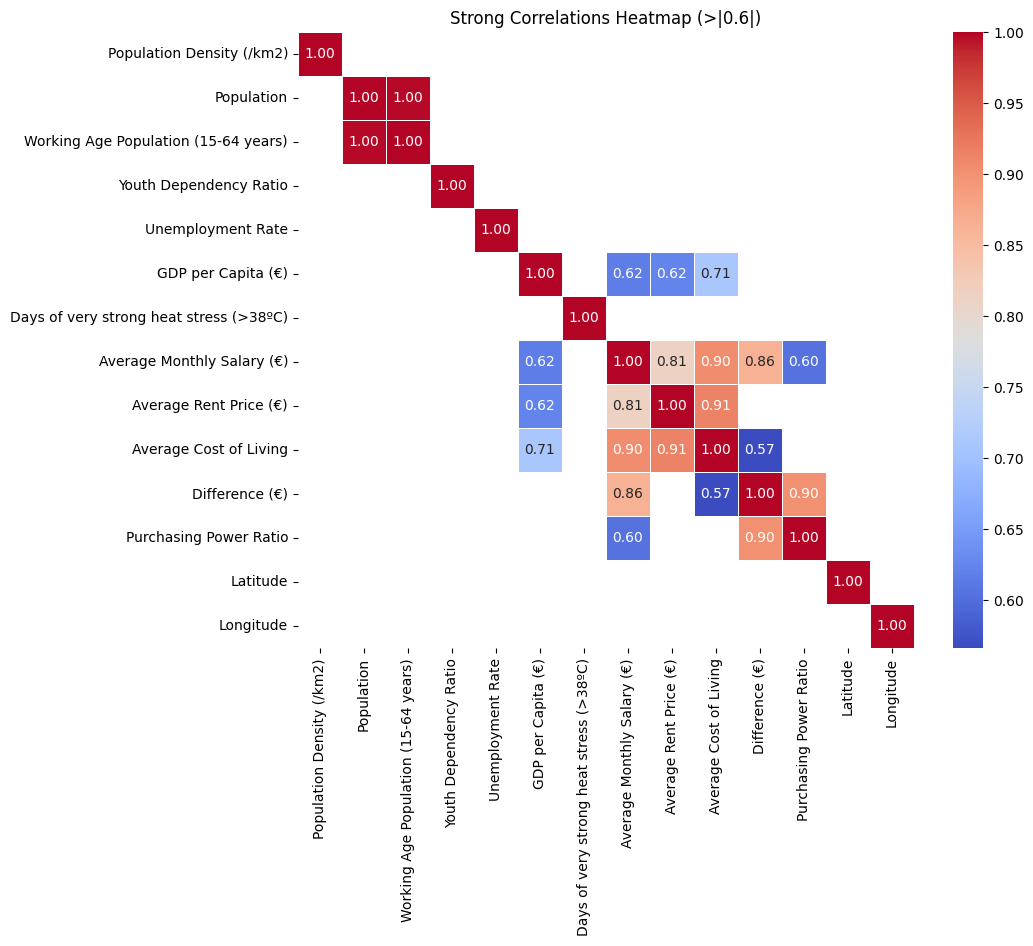

In [74]:
threshold = 0.55
filtered = corr_matrix.where(abs(corr_matrix) >= threshold)

plt.figure(figsize = (10, 8))
sns.heatmap(filtered, annot = True, square = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title('Strong Correlations Heatmap (>|0.6|)')
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
The piece of code below serves to provides better visualization, analysis and comprehension of the previous heatmap and see the correlation between the features.

In [75]:
correlation_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        variable_1 = corr_matrix.columns[i]
        variable_2 = corr_matrix.columns[j]
        correlation_value = corr_matrix.iloc[i, j]

        if abs(correlation_value) >= threshold:
            correlation_pairs.append((variable_1, variable_2, correlation_value))

correlation_pairs = sorted(correlation_pairs, key = lambda x: abs(x[2]), reverse = True)
for variable_1, variable_2, corr in correlation_pairs:
    print(f'Correlation between "{variable_1}" & "{variable_2}" : {corr:.3f}')

Correlation between "Population" & "Working Age Population (15-64 years)" : 0.998
Correlation between "Average Rent Price (€)" & "Average Cost of Living" : 0.915
Correlation between "Average Monthly Salary (€)" & "Average Cost of Living" : 0.905
Correlation between "Difference (€)" & "Purchasing Power Ratio" : 0.901
Correlation between "Average Monthly Salary (€)" & "Difference (€)" : 0.863
Correlation between "Average Monthly Salary (€)" & "Average Rent Price (€)" : 0.815
Correlation between "GDP per Capita (€)" & "Average Cost of Living" : 0.710
Correlation between "GDP per Capita (€)" & "Average Rent Price (€)" : 0.623
Correlation between "GDP per Capita (€)" & "Average Monthly Salary (€)" : 0.616
Correlation between "Average Monthly Salary (€)" & "Purchasing Power Ratio" : 0.605
Correlation between "Average Cost of Living" & "Difference (€)" : 0.566


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h4><b>4.2 Rules for city selection </b></h4>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
**A better and more useful visualization:**
We are not in that part of the code already but since we want to do combinations between variables and, for these combinations, some calculus would be done, we had to transform every variable into a numeric variable. In this case we are not looking at 'Which languages are mainly spoken in each country?' but 'How many languages are mainly spoken in each country?'.

In [76]:
def count_languages(series):
    return (series.fillna('').apply(lambda x: len([l for l in x.split(',') if l.strip()]) if isinstance(x, str) else 0))

dataset['Main Spoken Languages Count'] = count_languages(dataset['Main Spoken Languages'])

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
In the code below, we ask the user for an age and monthly income and we retrive the **social category in which, the values the user chose, are inserted in.** \
**For example:** if the user insert in age, 35, and in monthly income, 1000, the code will return *"You are a poor adult".*

In [77]:
age = int(input('Insert your age: '))
income = int(input('Insert your monthly income: ')) 

def category_age(age):
    if age < 18:
        return 'child'
    elif 18 <= age <= 64:
        return 'adult' 
    else:
        return 'elderly'


def category_income(income):
    if income < 1200:
        return 'poor'
    elif 1200 <= income <= 20000:
        return 'middle-class'
    else:
        return 'rich'

print(f'You are a {category_income(income)} {category_age(age)}.')

You are a middle-class adult.


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
Here are the **predefined categories** and the most possible interests each category could have. The division of interests was based in the **input variables 'age' and 'montlhy income'** and in the **variables we have in our dataset.**

In [78]:
Interests_per_categories = {
    ('child', 'poor'):        ['Population Density (/km2)', 'Youth Dependency Ratio', 'Average Rent Price (€)', 'Average Cost of Living'],
    ('child', 'middle-class'): ['Population Density (/km2)', 'Youth Dependency Ratio', 'Days of very strong heat stress (>38ºC)' , 'Average Cost of Living'],
    ('child', 'rich'):        ['Population Density (/km2)', 'Youth Dependency Ratio', 'Days of very strong heat stress (>38ºC)', 'Main Spoken Languages'],

    ('adult', 'poor'):          ['Average Cost of Living', 'Unemployment Rate', 'Average Rent Price (€)', 'Average Monthly Salary (€)'],
    ('adult', 'middle-class'):  ['Average Cost of Living', 'Average Monthly Salary (€)', 'Average Rent Price (€)' , 'GDP per Capita (€)'],
    ('adult', 'rich'):          ['Average Cost of Living', 'GDP per Capita (€)', 'Days of very strong heat stress (>38ºC)', 'Main Spoken Languages'],

    ('elderly', 'poor'):        ['Average Cost of Living', 'Population Density (/km2)', 'Working Age Population (15-64 years)', 'Average Rent Price (€)'],
    ('elderly', 'middle-class'): ['Average Cost of Living', 'Population Density (/km2)', 'Days of very strong heat stress (>38ºC)', 'Average Rent Price (€)'],
    ('elderly', 'rich'):        ['Population Density (/km2)', 'Days of very strong heat stress (>38ºC)', 'Average Cost of Living', 'Main Spoken Languages']
}

In [79]:
def norm(s):
    return s.strip().lower()
    
common_alias = {norm('population density (/km2)'): 'Population Density (/km2)',
    norm('youth dependency ratio'): 'Youth Dependency Ratio',
    norm('average rent price (€)'): 'Average Rent Price (€)',
    norm('average cost of living'): 'Average Cost of Living',
    norm('gdp per capita (€)'): 'GDP per Capita (€)',
    norm('unemployment rate'): 'Unemployment Rate',
    norm('days of very strong heat stress (>38ºC)'): 'Days of very strong heat stress (>38ºC)',
    norm('main spoken languages'): 'Main Spoken Languages', 
    norm('average monthly salary (€)') : 'Average Monthly Salary (€)',
    norm('working age population (15-64 years)') : 'Working Age Population (15-64 years)', 
}

In [80]:
column_map = {
    norm('Population Density (/km2)') : 'Population Density (/km2)',
    norm('Youth Dependency Ratio') : 'Youth Dependency Ratio',
    norm('Average Rent Price (€)') : 'Average Rent Price (€)',
    norm('Average Cost of Living') : 'Average Cost of Living',
    norm('Unemployment Rate') : 'Unemployment Rate',
    norm('Average Monthly Salary (€)') : 'Average Monthly Salary (€)',
    norm('Days of very strong heat stress (>38ºC)') : 'Days of very strong heat stress (>38ºC)',
    norm('Main Spoken Languages') : 'Main Spoken Languages',
    norm('GDP per Capita (€)') : 'GDP per Capita (€)',
    norm('Working Age Population (15-64 years)') : 'Working Age Population (15-64 years)'
}

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

Here we created all the possible combos that the user could do and defined between them a formula (or calculus) that would related the two variables chosen by the user into a meaningful variable that would add information for the user.

In [81]:
possible_combos = {
    ('Population Density (/km2)', 'Youth Dependency Ratio'): {'formula': 'multiplied by', 'order': (norm('Population Density (/km2)'), norm('Youth Dependency Ratio'))
                                                             },
    ('Population Density (/km2)', 'Average Rent Price (€)'): {'formula': 'divided by', 'order' :(norm('Average Rent Price (€)'), norm('Population Density (/km2)'))
                                                             },
    ('Population Density (/km2)', 'Average Cost of Living'): {'formula': 'multiplied by', 'order': (norm('Population Density (/km2)'), norm('Average Cost of Living'))
                                                             },
    ('Youth Dependency Ratio', 'Average Rent Price (€)'): {'formula': 'multiplied by', 'order': (norm('Youth Dependency Ratio'), norm('Average Rent Price (€)'))
                                                          },
    ('Youth Dependency Ratio', 'Average Cost of Living'): {'formula': 'multiplied by', 'order': (norm('Youth Dependency Ratio'), norm('Average Cost of Living'))
                                                          },
    ('Average Rent Price (€)', 'Average Cost of Living'): {'formula': 'divided by', 'order': (norm('Average Rent Price (€)'), norm('Average Cost of Living'))
                                                          },
    ('Population Density (/km2)', 'Days of very strong heat stress (>38ºC)'): {'formula': 'multiplied by', 'order': (norm('Population Density (/km2)'), norm('Days of very strong heat stress (>38ºC)'))
                                                                              },
    ('Youth Dependency Ratio', 'Days of very strong heat stress (>38ºC)'): {'formula': 'multiplied by', 'order': (norm('Youth Dependency Ratio'), norm('Days of very strong heat stress (>38ºC)'))
                                                                           },
    ('Days of very strong heat stress (>38ºC)', 'Average Cost of Living'): {'formula': 'multiplied by', 'order': (norm('Days of very strong heat stress (>38ºC)'), norm('Average Cost of Living'))
                                                                           },
    ('Population Density (/km2)', 'Main Spoken Languages'): {'formula': 'divided by', 'order': (norm('Main Spoken Languages'), norm('Population Density (/km2)'))
                                                            },
    ('Youth Dependency Ratio', 'Main Spoken Languages'): {'formula': 'multiplied by', 'order': (norm('Youth Dependency Ratio'), norm('Main Spoken Languages'))
                                                         },
    ('Days of very strong heat stress (>38ºC)', 'Main Spoken Languages'): {'formula': 'multiplied by', 'order': (norm('Days of very strong heat stress (>38ºC)'), norm('Main Spoken Languages'))
                                                                          },
    ('Average Cost of Living', 'Unemployment Rate'): {'formula': 'multiplied by', 'order': (norm('Average Cost of Living'), norm('Unemployment Rate'))
                                                     },
    ('Average Cost of Living', 'Average Monthly Salary (€)'): {'formula': 'divided by', 'order': (norm('Average Monthly Salary (€)'), norm('Average Cost of Living'))
                                                              },
    ('Unemployment Rate', 'Average Rent Price (€)'): {'formula': 'multiplied by', 'order': (norm('Unemployment Rate'), norm('Average Rent Price (€)'))
                                                     },
    ('Unemployment Rate', 'Average Monthly Salary (€)'): {'formula': 'multiplied by', 'order': (norm('Unemployment Rate'), norm('Average Monthly Salary (€)'))
                                                         },
    ('Average Rent Price (€)', 'Average Monthly Salary (€)'): {'formula': 'divided by', 'order': (norm('Average Rent Price (€)'), norm('Average Monthly Salary (€)'))
                                                              },
    ('Average Cost of Living', 'GDP per Capita (€)'): {'formula': 'divided by', 'order': (norm('Average Cost of Living'), norm('GDP per Capita (€)'))
                                                      },
    ('Average Monthly Salary (€)', 'GDP per Capita (€)'): {'formula': '*12 divided by', 'order': (norm('Average Monthly Salary (€)'), norm('GDP per Capita (€)'))
                                                          },
    ('Average Rent Price (€)', 'GDP per Capita (€)'): {'formula': '12* divided by', 'order': (norm('Average Rent Price (€)'), norm('GDP per Capita (€)'))
                                                      },
    ('Average Cost of Living', 'Days of very strong heat stress (>38ºC)'): {'formula': 'multiplied by', 'order': (norm('Average Cost of Living'), norm('Days of very strong heat stress (>38ºC)'))
                                                                           },
    ('Average Cost of Living', 'Main Spoken Languages'): {'formula': 'divided by', 'order': (norm('Average Cost of Living'), norm('Main Spoken Languages'))
                                                         },
    ('GDP per Capita (€)', 'Days of very strong heat stress (>38ºC)'): {'formula': 'multiplied by', 'order': (norm('GDP per Capita (€)'), norm('Days of very strong heat stress (>38ºC)'))
                                                                       },
    ('GDP per Capita (€)', 'Main Spoken Languages'): {'formula': 'divided by', 'order': (norm('GDP per Capita (€)'), norm('Main Spoken Languages'))
                                                     },
    ('Average Cost of Living', 'Working Age Population (15-64 years)'): {'formula': 'divided by', 'order': (norm('Working Age Population (15-64 years)'), norm('Average Cost of Living'))
                                                                        },
    ('Population Density (/km2)', 'Working Age Population (15-64 years)'): {'formula': '/population multiplied by', 'order': (norm('Population Density (/km2)'), norm('Working Age Population (15-64 years)'))
                                                                           },
    ('Average Rent Price (€)', 'Working Age Population (15-64 years)'): {'formula': 'divided by', 'order': (norm('Average Rent Price (€)'), norm('Working Age Population (15-64 years)'))
                                                                        },
    ('Days of very strong heat stress (>38ºC)', 'Average Rent Price (€)'): {'formula': 'multiplied by', 'order': (norm('Days of very strong heat stress (>38ºC)'), norm('Average Rent Price (€)'))
                                                                           }
}

normed_combos = {}
for key, value in possible_combos.items():
    norm_key = tuple(sorted((norm(key[0]), norm(key[1]))))
    
    norm_order = (norm(value['order'][0]), norm(value['order'][1]))
    
    normed_combos[norm_key] = {
        'formula': value['formula'],
        'order': norm_order,
    }

possible_combos = normed_combos

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
    
Here we **associate** each **combo variable** that the user could create to a **meaning and explanation.** 

In [82]:
combo_messages = {
    tuple(sorted((norm('Population Density (/km2)'), norm('Youth Dependency Ratio')))): 'Youth Pressure Index - Measures how concentrated young dependents are in a given area. High values suggest potential strain on schools, housing, and services.',
    tuple(sorted((norm('Population Density (/km2)'), norm('Average Rent Price (€)')))): 'Housing Pressure Index - Shows how rent prices scale relative to density. High rent with low density may indicate exclusivity; high rent with high density suggests affordability stress.',
    tuple(sorted((norm('Population Density (/km2)'), norm('Average Cost of Living')))): 'Urban Cost Index - Captures how expensive dense areas are. Useful for comparing urban vs. rural affordability.',
    tuple(sorted((norm('Youth Dependency Ratio'), norm('Average Rent Price (€)')))): 'Youth Housing Burden - Indicates how rent costs may affect households with many dependents.', 
    tuple(sorted((norm('Youth Dependency Ratio'), norm('Average Cost of Living')))): 'Family Cost Burden - Reflects the financial stress on families with many young dependents.',
    tuple(sorted((norm('Average Rent Price (€)'), norm('Average Cost of Living')))): 'Housing Share of Living Costs - Shows what fraction of living costs is consumed by rent — a key affordability metric.',
    tuple(sorted((norm('Population Density (/km2)'), norm('Days of very strong heat stress (>38ºC)')))): 'Urban Heat Exposure - Measures how many people are exposed to extreme heat in dense areas.',
    tuple(sorted((norm('Youth Dependency Ratio'), norm('Days of very strong heat stress (>38ºC)')))): 'Youth Climate Vulnerability - Highlights how climate stress disproportionately affects young dependents.',
    tuple(sorted((norm('Average Cost of Living'), norm('Days of very strong heat stress (>38ºC)')))): 'Climate-Cost Burden - Captures how climate stress interacts with financial stress.',
    tuple(sorted((norm('Population Density (/km2)'), norm('Main Spoken Languages')))): 'Language Diversity Index - Shows how diverse languages are concentrated in dense areas.', 
    tuple(sorted((norm('Youth Dependency Ratio'), norm('Main Spoken Languages')))): 'Youth Linguistic Diversity - Indicates how multilingual environments affect younger populations.',
    tuple(sorted((norm('Days of very strong heat stress (>38ºC)'), norm('Main Spoken Languages')))): 'Climate-Language Exposure - Useful for policy — ensuring climate warnings reach diverse linguistic groups.',
    tuple(sorted((norm('Average Cost of Living'), norm('Unemployment Rate')))): 'Economic Stress Index - High living costs combined with high unemployment indicate severe economic pressure.',
    tuple(sorted((norm('Average Cost of Living'), norm('Average Monthly Salary (€)')))): 'Affordability Ratio - Indicates whether salaries are sufficient to cover living costs. Values < 1 suggest financial strain.',
    tuple(sorted((norm('Unemployment Rate'), norm('Average Rent Price (€)')))): 'Unemployment Housing Burden - Reflects how unemployment interacts with rent costs, highlighting vulnerability in housing markets.',
    tuple(sorted((norm('Unemployment Rate'), norm('Average Monthly Salary (€)')))): 'Labor Market Stress Index - Shows the potential income lost due to unemployment.',
    tuple(sorted((norm('Average Rent Price (€)'), norm('Average Monthly Salary (€)')))): 'Rent-to-Income Ratio - A classic affordability metric. Ratios above 30% are considered housing stress.',
    tuple(sorted((norm('Average Cost of Living'), norm('GDP per Capita (€)')))): 'Living Cost Burden - Compares national wealth per person with actual living expenses.',
    tuple(sorted((norm('Average Monthly Salary (€)'), norm('GDP per Capita (€)')))): 'Income Distribution Index - Shows how much of GDP per capita is reflected in average wages. Low values suggest inequality.',
    tuple(sorted((norm('Average Rent Price (€)'), norm('GDP per Capita (€)')))): 'Rent Burden Index - Indicates how much of GDP per capita is consumed by rent annually.',
    tuple(sorted((norm('Average Cost of Living'), norm('Days of very strong heat stress (>38ºC)')))): 'Climate-Cost Stress Index - Captures combined financial and climate stress.',
    tuple(sorted((norm('Average Cost of Living'), norm('Main Spoken Languages')))): 'Cost Diversity - Highlights how diverse linguistic communities experience living costs.',
    tuple(sorted((norm('GDP per Capita (€)'), norm('Days of very strong heat stress (>38ºC)')))): 'Climate-Economic Exposure - Measures how economic wealth interacts with climate vulnerability.',
    tuple(sorted((norm('GDP per Capita (€)'), norm('Main Spoken Languages')))): 'GDP Diversity - Shows how wealth per person is distributed across linguistic groups.',
    tuple(sorted((norm('Average Cost of Living'), norm('Working Age Population (15-64 years)')))): 'Affordability capacity - Higher values suggest more potential earners relative to living costs.',
    tuple(sorted((norm('Population Density (/km2)'), norm('Working Age Population (15-64 years)')))): 'Working-age Density - Concentration of working-age residents per area.',
    tuple(sorted((norm('Average Rent Price (€)'), norm('Working Age Population (15-64 years)')))): 'Rent Burden per Worker - Signals how rent pressure scales with the available workforce.',
    tuple(sorted((norm('Average Rent Price (€)'), norm('Days of very strong heat stress (>38ºC)')))): 'Climate–housing stress index - Captures concurrent environmental and housing pressures.'
}

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 

Here we are just defining the formulas that will relate the two variables chosen. Each formula will give an extra information value for the user.

In [83]:
def combine_columns(dataset, column_1, column_2, formula):

    if formula == 'multiplied by':
        return dataset[column_1] * dataset[column_2]

    elif formula == 'divided by':
        return dataset[column_1] / dataset[column_2]

    elif formula == '*12 divided by':
        return dataset[column_1] * 12 / dataset[column_2]

    elif formula == '/population multiplied by':
        return dataset[column_1] * dataset[column_2] / dataset['Population']

    elif formula == 'numeric x language count':
        return dataset[column_1] * dataset[column_2]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
And here are our main functions. This is how the TOP5's are made and how the heatmap is shown after the user made his choice(s).

In [84]:
def suggest_options(age, income):
    age_cat = category_age(age)
    income_cat = category_income(income)
    user_profile = (age_cat, income_cat)
    available_options = Interests_per_categories.get(user_profile, [])
    return available_options

import plotly.express as px

def analyze_variable(dataset, variable_column):

    if pd.api.types.is_numeric_dtype(dataset[variable_column]):
        sorted_descending_dataset = dataset.sort_values(by = variable_column, ascending = False)
        sorted_ascending_dataset = dataset.sort_values(by = variable_column, ascending = True)

        bottom5 = sorted_ascending_dataset[['City', variable_column]].head(5)

        print(f'\nTop 5 countries with highest {variable_column}.')
        top5 = sorted_descending_dataset[['City', variable_column]].head(5)
        print(top5.to_string(index = False))

        print(f'\nTop 5 countries with lowest {variable_column}.')
        bottom5 = sorted_ascending_dataset[['City', variable_column]].head(5)
        print(bottom5.to_string(index = False))

    else:
        counts = dataset[variable_column].value_counts()

        print(f'\nTop 5 most common {variable_column}:')
        top5 = counts.head(5)
        print(top5.to_string())

        print(f'\n5 least common {variable_column}:')
        bottom5 = counts.tail(5)
        print(bottom5.to_string())

    fig = px.scatter_geo(
        dataset,
        lat = 'Latitude',
        lon = 'Longitude',
        color = variable_column,
        hover_name = 'City',
        title = f'{variable_column} - Heatmap',
)
    fig.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
Here is just the displaying of the user's options and some restrictions for valid answers only.

In [88]:
available_options = suggest_options(age, income)
print(f'Choose the topic that matters to you the most: {available_options}')

first_choice = input('What is your choice: ').lower().strip()
available_lower = [options.lower() for options in available_options]

second_choice=None
second_variable_column=None

while first_choice not in available_lower:
    first_choice = input('Inexistent topic. Try again: ').lower().strip()

variable_column = common_alias[first_choice]
decision = input('Do you want to choose another topic? Type "yes/y" or "no/n" ').lower().strip()

while decision not in ['no','n', 'yes', 'y']:
    decision = input('Invalid input. Type "yes/y" or "no/n": ').strip().lower()

if decision in ['no','n']:
    analyze_variable(dataset, variable_column)
else:
     second_choice = input('Choose another variable to combine with this one: ').lower().strip()
     while second_choice not in available_lower or second_choice == first_choice:
         second_choice = input('Inexistent or already selected topic. Select a different variable: ').lower().strip()
     second_variable_column = common_alias[second_choice]
     print(f'Your choices are {variable_column} & {second_variable_column}.')

Choose the topic that matters to you the most: ['Average Cost of Living', 'Average Monthly Salary (€)', 'Average Rent Price (€)', 'GDP per Capita (€)']
Your choices are Average Cost of Living & Average Monthly Salary (€).


In [89]:
possible_combos = {
    (norm(k1), norm(k2)): v
    for (k1, k2), v in possible_combos.items()
}
def resolve_column(var_name):
    if norm(var_name) == norm('Main Spoken Languages'):
        return 'Main Spoken Languages Count'
    else:
        return column_map[norm(var_name)]

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px"> 
And this is the trigger that passes the user's combo (two variables chosen) to our main function, that will output what the user wants to see.

In [90]:
first = norm(first_choice)

if second_choice is None: 
    print("It is impossible to have a combo because the user didn't have a second choice")
else: 
    second = norm(second_choice)
    combo_key = tuple(sorted((first, second)))

    if combo_key in combo_messages:
        print(combo_messages[combo_key])
    else:
        print('No message defined for this combination.')

    if combo_key in possible_combos:

        combo = possible_combos[combo_key]
        ordered_first, ordered_second = combo['order']
        formula = combo['formula']

        col1 = resolve_column(ordered_first)
        col2 = resolve_column(ordered_second)

        dataset['Result'] = combine_columns(dataset, col1, col2, formula)

        analyze_variable(dataset, 'Result')

    else:
        print('This combination is not allowed.')

Affordability Ratio - Indicates whether salaries are sufficient to cover living costs. Values < 1 suggest financial strain.

Top 5 countries with highest Result.
    City   Result
 Tampere 2.187500
   Ghent 2.000000
 Seville 2.000000
 Dresden 1.993464
Helsinki 1.902439

Top 5 countries with lowest Result.
        City   Result
      Lisbon 0.762500
       Porto 0.785714
      Athens 0.875000
Thessaloniki 0.909091
       Braga 0.909091


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">
<h3><b> 5. Conclusion </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #357AF6;">


## **Final Conclusions**

This notebook successfully develops a data-driven framework to **support informed decisions about where to live in Europe**, aligning closely with the project’s objective of **translating complex city-level data into clear, actionable insights**. Through systematic **data wrangling, exploratory analysis, and visualization**, the analysis highlights that quality of life cannot be assessed through single indicators such as salary or city size alone. Instead, **meaningful comparisons** require combining **multiple dimensions**, including **purchasing power, unemployment, economic performance, and data timeliness.**

The results show **substantial heterogeneity across European cities**. Cities with the **highest salaries** often face equally **high living costs**, while others offer more **favorable salary–cost balances**. Similarly, unemployment rates tend to be lower in economically stronger cities, as reflected in the negative relationship between GDP per capita and unemployment, although this relationship is not deterministic. Importantly, **population size alone does not explain differences in cost of living**, reinforcing the need for contextual, multi-variable analysis.

Beyond the required questions, **additional insights such as identifying cities that simultaneously combine low unemployment with high purchasing power** add **practical value** and **strengthen** the decision-making perspective of the project. The advanced topic further enhances the **analysis by integrating web-scraped geographical data into an interactive map**, enabling **intuitive exploration of cities and reinforcing the connection between data analysis and real-world usability.**

Overall, the notebook demonstrates that **balanced economic conditions**, rather than **extreme values in isolated indicators**, are the **most reliable signals of attractive living conditions.**

 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
     
<b> **Git Hub link** - https://github.com/tiago2806/PDS_Project
    